# Lab 05: RNNs vs. Transformers vs. Vision Transformers
## ITAI 2376 — Deep Learning | Spring 2026
### Houston City College — AI & Robotics Program

---

**Welcome to Lab 05!** This is a comprehensive, hands-on lab where you will build, train, and compare three major deep learning architectures:

| Part | Architecture | Task | Dataset |
|------|-------------|------|---------|
| **A** | LSTM & GRU (RNNs) | News Topic Classification | AG News |
| **B** | DistilBERT (Transformer) | News Topic Classification | AG News (same data!) |
| **C** | Vision Transformer (ViT) | Image Classification | CIFAR-10 |
| **D** | — | Comparative Analysis & Reflection | All results |

**Why this lab matters:** By using the *same text dataset* for both RNNs and Transformers, you get a direct, apples-to-apples comparison. Then, by exploring Vision Transformers, you see how the Transformer idea extends beyond text into images — and you can compare ViT performance to the CNNs you built in Module 03.

**Estimated Time:** 3–4 hours  
**Environment:** Google Colab (free tier is sufficient)

---

⚠️ **Important:** Run cells in order. If you restart the runtime, re-run all cells from the top.

---
## Part 0: Environment Setup

First, let's install libraries and check GPU access. GPU is not strictly required but makes training much faster.

**If no GPU:** Runtime → Change runtime type → T4 GPU. If unavailable, reduce epochs or dataset size as noted in the troubleshooting section at the end.

In [1]:
# Cell 0.1 — Install Required Libraries
# This cell installs the external libraries needed for this lab:
#   - transformers: Hugging Face library for pre-trained models (BERT, ViT)
#   - datasets: Hugging Face library for loading standard datasets (AG News, CIFAR-10)
#   - accelerate: Helps optimize training on different hardware (GPU/CPU)
# The -q flag makes installation quiet (less verbose output)

!pip install transformers datasets accelerate -q
print("✅ Libraries installed!")

✅ Libraries installed!


In [52]:
# Cell 0.2 — Import Core Libraries and Check GPU Availability

# ========== DEEP LEARNING FRAMEWORK ==========
import torch                          # PyTorch: main deep learning framework
import torch.nn as nn                 # Neural network modules (layers, loss functions)
import torch.optim as optim           # Optimization algorithms (Adam, SGD, etc.)
from torch.utils.data import DataLoader, Dataset  # Data loading utilities for batching

# ========== DATA PROCESSING ==========
import numpy as np                    # Numerical operations on arrays
from collections import Counter       # Count word frequencies for vocabulary building
import re                             # Regular expressions for text cleaning

# ========== VISUALIZATION ==========
import matplotlib.pyplot as plt       # Plotting library for charts and graphs

# ========== UTILITIES ==========
import time                           # Track training time per epoch
import warnings                       # Suppress non-critical warnings
warnings.filterwarnings('ignore')     # Hide deprecation and other warnings for cleaner output

# ========== HUGGING FACE LIBRARIES (imported later when needed) ==========
# from datasets import load_dataset   # For loading AG News dataset
# from transformers import ...        # For DistilBERT and ViT models
# from torchvision import ...         # For CIFAR-10 dataset and image transforms

# ========== DEVICE CONFIGURATION ==========
# Check if CUDA-enabled GPU is available; otherwise use CPU
# Training on GPU is 10-50x faster than CPU for deep learning
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device: {device}")

if device.type == 'cuda':
    # Display GPU name (e.g., Tesla T4, A100)
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
else:
    print("   ⚠️  No GPU detected. Training will be slower. See troubleshooting tips at end.")

🖥️  Device: cuda
   GPU: Tesla T4


---
# Part A: RNN Text Classification (LSTM & GRU)

In Module 04, you learned about Recurrent Neural Networks — architectures that process sequences step by step, maintaining a hidden state that acts as "memory." Now you put that knowledge into practice.

**Your task:** Build LSTM and GRU classifiers to categorize news articles into four topics:
- 🌍 **World** — international news
- 🏈 **Sports** — athletic events
- 💼 **Business** — financial and corporate news
- 🔬 **Sci/Tech** — science and technology

We use the **AG News** dataset — a well-known benchmark. We use a subset to keep training fast on free Colab.

### Step A.1 — Load and Explore AG News

In [3]:
# Cell A.1 — Load AG News Dataset
# Import the Hugging Face datasets library for easy access to standard datasets
from datasets import load_dataset

# Load the AG News dataset (4-class news topic classification)
# This dataset contains news articles labeled as: World, Sports, Business, Sci/Tech
dataset = load_dataset("ag_news")

# Define subset sizes to keep training time reasonable on free Colab
TRAIN_SIZE = 8000  # 2000 samples per class (4 classes × 2000 = 8000)
TEST_SIZE  = 2000  # 500 samples per class (4 classes × 500 = 2000)

# Shuffle and select subsets (seed=42 ensures reproducibility)
train_data = dataset['train'].shuffle(seed=42).select(range(TRAIN_SIZE))
test_data  = dataset['test'].shuffle(seed=42).select(range(TEST_SIZE))

# Define human-readable class names (labels are 0, 1, 2, 3)
CLASS_NAMES = ['World', 'Sports', 'Business', 'Sci/Tech']

# Display dataset information
print(f"Training samples: {len(train_data)}")
print(f"Test samples:     {len(test_data)}")
print(f"\n--- Sample article ---")
print(f"Label: {CLASS_NAMES[train_data[0]['label']]}")
print(f"Text:  {train_data[0]['text'][:300]}...")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

Training samples: 8000
Test samples:     2000

--- Sample article ---
Label: World
Text:  Bangladesh paralysed by strikes Opposition activists have brought many towns and cities in Bangladesh to a halt, the day after 18 people died in explosions at a political rally....


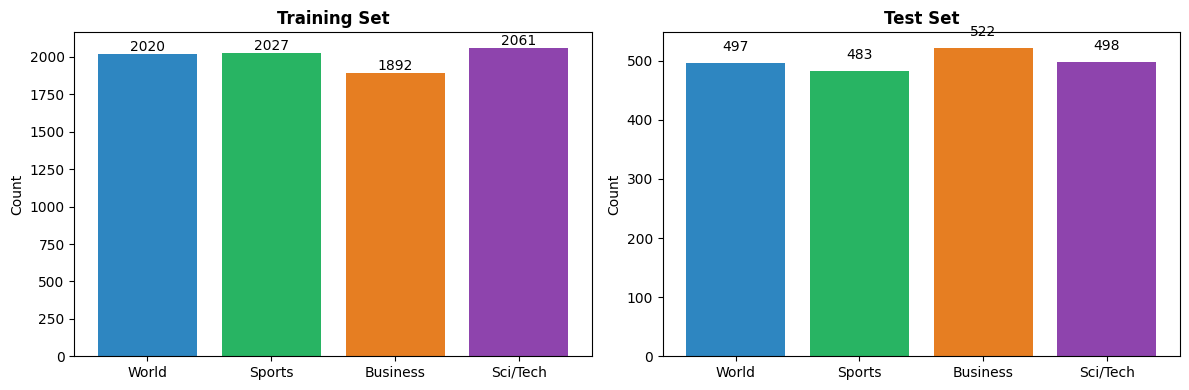

In [4]:
# Cell A.2 — Visualize Class Distribution
# It's important to check if classes are balanced (equal representation)
# Imbalanced datasets can bias the model toward majority classes

# Extract labels from training and test sets
train_labels = [s['label'] for s in train_data]
test_labels = [s['label'] for s in test_data]

# Create side-by-side bar charts
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, labels, title in zip(axes, [train_labels, test_labels], ['Training Set', 'Test Set']):
    # Count occurrences of each class
    counts = Counter(labels)
    # Create bar chart with distinct colors for each class
    bars = ax.bar(CLASS_NAMES, [counts[i] for i in range(4)],
                   color=['#2E86C1','#28B463','#E67E22','#8E44AD'])
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Count')
    # Add count labels on top of each bar
    for bar, c in zip(bars, [counts[i] for i in range(4)]):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+20,
                str(c), ha='center')

plt.tight_layout()
plt.show()

### Step A.2 — Text Preprocessing

Neural networks cannot process raw text. We need to:
1. **Tokenize** — split text into words
2. **Build a vocabulary** — assign a unique number to each word
3. **Convert to sequences** — replace words with numbers
4. **Pad sequences** — make all sequences the same length for batching

This is the same pipeline from Module 04, implemented from scratch.

In [5]:
# Cell A.3 — Build Vocabulary and Preprocess Text

def tokenize(text):
    """
    Convert text to lowercase and split into words.

    Steps:
    1. Convert to lowercase ("Hello" and "hello" should be the same word)
    2. Remove punctuation and special characters (keep only letters, numbers, spaces)
    3. Split on whitespace to get individual words

    Example: "Hello, World!" → ["hello", "world"]
    """
    text = text.lower()                      # Convert to lowercase
    text = re.sub(r'[^a-z0-9\s]', '', text)  # Remove punctuation
    return text.split()                      # Split into words

# Count word frequencies across all training documents
# This helps us identify the most common words to include in our vocabulary
word_counts = Counter()
for sample in train_data:
    word_counts.update(tokenize(sample['text']))

# ========== VOCABULARY PARAMETERS ==========
VOCAB_SIZE = 10000  # Keep only the 10,000 most common words
MAX_LEN = 128       # Truncate/pad all sequences to 128 tokens
PAD_IDX = 0         # Index for padding token (fills shorter sequences)
UNK_IDX = 1         # Index for unknown words (not in vocabulary)

# Select the top (VOCAB_SIZE - 2) most common words
# We reserve indices 0 and 1 for <PAD> and <UNK>
most_common = word_counts.most_common(VOCAB_SIZE - 2)

# Create word-to-index mapping (dictionary)
# Each word gets a unique integer ID starting from 2
word2idx = {word: idx+2 for idx, (word, _) in enumerate(most_common)}
word2idx['<PAD>'] = PAD_IDX  # Special token for padding
word2idx['<UNK>'] = UNK_IDX  # Special token for unknown words

print(f"Vocabulary size: {len(word2idx):,}")
print(f"Max sequence length: {MAX_LEN}")
print(f"Top 10 words: {[w for w, _ in most_common[:10]]}")

Vocabulary size: 10,000
Max sequence length: 128
Top 10 words: ['the', 'to', 'a', 'of', 'in', 'and', 'on', 'for', '39s', 'that']


In [6]:
# Cell A.4 — Create PyTorch Dataset
# PyTorch requires data in a specific format for efficient batching and loading

class NewsDataset(Dataset):
    """
    Custom PyTorch Dataset for AG News.

    Converts raw text into:
    - Padded sequences of word indices (input for the model)
    - Integer labels (target for classification)
    """
    def __init__(self, data, word2idx, max_len):
        self.texts, self.labels = [], []

        for sample in data:
            # Step 1: Tokenize text and convert words to indices
            # If a word is not in vocabulary, use UNK_IDX
            indices = [word2idx.get(w, UNK_IDX) for w in tokenize(sample['text'])[:max_len]]

            # Step 2: Pad sequence to max_len (add PAD_IDX to the end)
            # This ensures all sequences have the same length for batching
            indices += [PAD_IDX] * (max_len - len(indices))

            # Step 3: Convert to PyTorch tensor
            self.texts.append(torch.tensor(indices, dtype=torch.long))
            self.labels.append(sample['label'])

        # Convert labels to tensor
        self.labels = torch.tensor(self.labels, dtype=torch.long)

    def __len__(self):
        """Return the number of samples in the dataset."""
        return len(self.labels)

    def __getitem__(self, idx):
        """Return a single sample (text, label) at the given index."""
        return self.texts[idx], self.labels[idx]

# ========== CREATE DATASETS AND DATA LOADERS ==========
BATCH_SIZE = 64  # Process 64 samples at a time (adjust based on GPU memory)

# Create dataset objects
train_dataset = NewsDataset(train_data, word2idx, MAX_LEN)
test_dataset  = NewsDataset(test_data, word2idx, MAX_LEN)

# Create data loaders (handle batching and shuffling)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE)

# Display sample information
sample_text, sample_label = train_dataset[0]
print(f"Text tensor shape: {sample_text.shape}")
print(f"Label: {sample_label.item()} ({CLASS_NAMES[sample_label.item()]})")
print(f"Training batches: {len(train_loader)}")

Text tensor shape: torch.Size([128])
Label: 0 (World)
Training batches: 125


### Step A.3 — Build the LSTM Model

Architecture:
1. **Embedding layer** — converts word indices into dense vectors
2. **Bidirectional LSTM** — reads the sequence in both directions
3. **Fully connected layer** — maps LSTM output to 4 class predictions

In [7]:
# Cell A.5 — LSTM Classifier

class LSTMClassifier(nn.Module):
    """
    LSTM-based text classifier.

    Architecture:
    1. Embedding: Converts word indices to dense vectors (e.g., 5234 → [0.2, -0.5, ...])
    2. Bidirectional LSTM: Processes sequence forward and backward to capture context
    3. Dropout: Prevents overfitting by randomly dropping connections during training
    4. Fully Connected: Maps LSTM output to class probabilities
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()

        # Embedding layer: vocab_size × embed_dim matrix
        # Each word index is mapped to a dense vector of size embed_dim
        # padding_idx=PAD_IDX ensures padding tokens don't contribute to learning
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        # Bidirectional LSTM layer
        # - embed_dim: size of input vectors (from embedding)
        # - hidden_dim: size of hidden state (LSTM memory)
        # - batch_first=True: input shape is (batch, sequence, features)
        # - bidirectional=True: process sequence left-to-right AND right-to-left
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)

        # Dropout layer: randomly sets 30% of activations to zero during training
        # This prevents the model from relying too heavily on specific features
        self.dropout = nn.Dropout(dropout)

        # Fully connected layer: maps LSTM output to class scores
        # hidden_dim * 2 because bidirectional LSTM concatenates forward and backward outputs
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        """
        Forward pass through the network.

        Args:
            x: Input tensor of word indices, shape (batch_size, max_len)

        Returns:
            Class scores, shape (batch_size, num_classes)
        """
        # Step 1: Convert word indices to embeddings
        # Shape: (batch_size, max_len) → (batch_size, max_len, embed_dim)
        embedded = self.embedding(x)

        # Step 2: Pass through LSTM
        # output: all hidden states, shape (batch_size, max_len, hidden_dim * 2)
        # hidden: final hidden states, shape (2, batch_size, hidden_dim)
        #         [0] = forward direction, [1] = backward direction
        # cell: final cell states (not used for classification)
        output, (hidden, cell) = self.lstm(embedded)

        # Step 3: Concatenate final forward and backward hidden states
        # hidden[-2] = last forward hidden state
        # hidden[-1] = last backward hidden state
        # Result shape: (batch_size, hidden_dim * 2)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)

        # Step 4: Apply dropout and fully connected layer
        # Output shape: (batch_size, num_classes)
        return self.fc(self.dropout(hidden))

# ========== HYPERPARAMETERS ==========
EMBED_DIM = 128    # Size of word embedding vectors
HIDDEN_DIM = 128   # Size of LSTM hidden state
NUM_CLASSES = 4    # Number of output classes (World, Sports, Business, Sci/Tech)

# Create model and move to GPU (if available)
lstm_model = LSTMClassifier(len(word2idx), EMBED_DIM, HIDDEN_DIM, NUM_CLASSES).to(device)

# Count total trainable parameters
print(f"LSTM Parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")

LSTM Parameters: 1,545,220


### 📝 Knowledge Check A.1

1. **Why do we use `bidirectional=True`?** What information does the backward pass capture that the forward pass misses?
2. **What is the purpose of the Embedding layer?** How is it different from one-hot encoding?
3. **Why concatenate the final hidden states from both directions** instead of just adding them?

**Your answers:**

1. We use bidirectional=True because it processes the sequence in both directions, left-to-right and right-to-left. It's not that the forward pass misses something; it's more like the backward pass reveals something the forward pass cannot. And that is something, how much weight contributed to an error, allowing the network to adjust its parameters to reduce loss.

2. The purpose of the Embedding layer is to convert word indices into dense vectors. One-hot encoding models have to learn relationships from scratch later on, also being the simplest way to represent words and categories. While embedding captures meanings and relationships, it also understands semantic similarity.

3. Because bidirectional LTSM concatenates forward and backward hidden states, it preserves all the information from both directions. If we added them together, then the information would be mixed, and some details could be lost.

### Step A.4 — Build the GRU Model

GRUs have **two gates** (reset, update) vs. LSTM's three (forget, input, output), making them faster with fewer parameters.

**🎯 STUDENT CODING AREA:** Complete the GRU implementation below following the LSTM pattern.

In [12]:
# Cell A.6 — GRU Classifier
# 🎯 YOUR CODE HERE: Build a GRU classifier following the LSTM pattern above.
# Hints:
#   - Replace nn.LSTM with nn.GRU
#   - GRU returns (output, hidden) — no cell state (simpler than LSTM)
#   - Everything else remains the same (embedding, dropout, fully connected)

class GRUClassifier(nn.Module):
    """
    GRU-based text classifier.

    Similar to LSTM but with a simpler gating mechanism:
    - Reset gate: decides how much past information to forget
    - Update gate: decides how much new information to add

    No separate cell state (unlike LSTM), making it computationally faster.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()

        # Embedding layer (same as LSTM)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        # TODO: Create the GRU layer (bidirectional)
        # Hint: self.gru = nn.GRU(input_size, hidden_size, batch_first=True, bidirectional=True)
        # YOUR CODE HERE (replace pass with your GRU layer)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True, bidirectional=True)

        # Dropout and fully connected layers (same as LSTM)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        """
        Forward pass through the GRU network.

        Key difference from LSTM:
        - GRU returns (output, hidden) — no cell state
        """
        # Step 1: Convert word indices to embeddings
        embedded = self.embedding(x)

        # Step 2: Pass through GRU
        # TODO: GRU returns (output, hidden) — no cell state (unlike LSTM)
        # Hint: output, hidden = self.gru(embedded)
        # YOUR CODE HERE (replace pass with your GRU forward pass)
        output, hidden = self.gru(embedded)

        # Step 3: Concatenate final forward and backward hidden states
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)

        # Step 4: Apply dropout and fully connected layer
        return self.fc(self.dropout(hidden))

# Create GRU model and move to GPU
gru_model = GRUClassifier(len(word2idx), EMBED_DIM, HIDDEN_DIM, NUM_CLASSES).to(device)

# Compare parameter counts
print(f"GRU Parameters:  {sum(p.numel() for p in gru_model.parameters()):,}")
print(f"LSTM Parameters: {sum(p.numel() for p in lstm_model.parameters()):,}")
print(f"Difference: {sum(p.numel() for p in lstm_model.parameters()) - sum(p.numel() for p in gru_model.parameters()):,} fewer in GRU")

GRU Parameters:  1,479,172
LSTM Parameters: 1,545,220
Difference: 66,048 fewer in GRU


### 🎯 Student Coding Exercise A.7 — Build a Vanilla RNN Classifier

Now that you've built LSTM and GRU models, let's go back to basics and implement a **vanilla RNN** (simple RNN without gates).

**Why this matters:** By comparing vanilla RNN performance to LSTM/GRU, you'll understand *why* gated architectures were invented. Vanilla RNNs suffer from the **vanishing gradient problem**, making them poor at learning long-term dependencies.

**Your task:**
1. Create a `VanillaRNNClassifier` class similar to LSTM/GRU
2. Use `nn.RNN` instead of `nn.LSTM` or `nn.GRU`
3. Train it for 3 epochs
4. Compare accuracy to LSTM and GRU

**Hints:**
- `nn.RNN` has the same API as `nn.LSTM` and `nn.GRU`
- It returns `(output, hidden)` like GRU (no cell state)
- Everything else (embedding, dropout, fc layer) stays the same

In [23]:
# Cell A.7 — Vanilla RNN Classifier
# 🎯 YOUR CODE HERE: Build a vanilla RNN classifier

class VanillaRNNClassifier(nn.Module):
    """
    Simple RNN-based text classifier (no gates).

    This is the original RNN architecture before LSTM/GRU were invented.
    It struggles with long sequences due to vanishing gradients.
    """
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes, dropout=0.3):
        super().__init__()

         # Embedding layer (same as LSTM)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        # TODO: Implement the architecture
        # Hint: Use nn.RNN instead of nn.LSTM or nn.GRU
        # YOUR CODE HERE
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True, bidirectional=True)

        # Dropout and fully connected layers (same as LSTM)
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        """
        Forward pass through vanilla RNN.
        """
        # TODO: Implement forward pass
        # Hint: Same as GRU (returns output, hidden)
        # YOUR CODE HERE
        # Step 1: Convert word indices to embeddings
        embedded = self.embedding(x)

        # Corrected: use self.rnn instead of self.gru
        output, hidden = self.rnn(embedded)
        # Step 3: Concatenate final forward and backward hidden states
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)

        # Step 4: Apply dropout and fully connected layer
        return self.fc(self.dropout(hidden))


# TODO: Create and train the vanilla RNN model
# Hint: Follow the same pattern as LSTM/GRU training
# YOUR CODE HERE
rnn_model = VanillaRNNClassifier(len(word2idx), EMBED_DIM, HIDDEN_DIM, NUM_CLASSES).to(device)

# After training, compare results:
print("\n=== RNN Architecture Comparison ===")
print(f"Vanilla RNN Test Accuracy: ____%")  # Fill in your result
print(f"LSTM Test Accuracy:        ____%")  # From earlier
print(f"GRU Test Accuracy:         ____%")  # From earlier



=== RNN Architecture Comparison ===
Vanilla RNN Test Accuracy: ____%
LSTM Test Accuracy:        ____%
GRU Test Accuracy:         ____%


### Step A.4b — Train the Vanilla RNN

Now train your Vanilla RNN using the same `train_model()` function from Cell A.9, then compare all three RNN architectures side by side.

**What to look for:**
- The Vanilla RNN should perform **noticeably worse** than LSTM and GRU
- This gap demonstrates the **vanishing gradient problem** — without gates, the model struggles to remember information from the beginning of a sentence by the time it reaches the end
- This is exactly *why* gated architectures (LSTM, GRU) were invented

In [28]:
# Cell A.7b — Train Vanilla RNN
# Train the Vanilla RNN you built above using the same function used for LSTM and GRU

# Step 1: Create the Vanilla RNN model (same hyperparameters as LSTM/GRU)
vanilla_model = VanillaRNNClassifier(len(word2idx), EMBED_DIM, HIDDEN_DIM, NUM_CLASSES).to(device)

# Compare parameter counts across all three architectures
print(f"Vanilla RNN Parameters: {sum(p.numel() for p in vanilla_model.parameters()):,}")
print(f"GRU Parameters:         {sum(p.numel() for p in gru_model.parameters()):,}")
print(f"LSTM Parameters:        {sum(p.numel() for p in lstm_model.parameters()):,}")
print()

# Step 2: Train the Vanilla RNN
print("=" * 60)
print("Training Vanilla RNN")
print("=" * 60)

vanilla_history = train_model(vanilla_model, train_loader, test_loader, epochs=3, name="Vanilla RNN")

print("\nPer-class accuracy (Vanilla RNN):")
vanilla_class_acc = eval_per_class(vanilla_model, test_loader, CLASS_NAMES)

Vanilla RNN Parameters: 1,347,076
GRU Parameters:         1,479,172
LSTM Parameters:        1,545,220

Training Vanilla RNN
  Epoch 1/3 | Loss: 1.3112 | Train: 0.3749 | Test: 0.4660 | 0.5s
  Epoch 2/3 | Loss: 1.0841 | Train: 0.5423 | Test: 0.5790 | 0.4s
  Epoch 3/3 | Loss: 0.8442 | Train: 0.6779 | Test: 0.6345 | 0.4s

Per-class accuracy (Vanilla RNN):
  World     : 0.6519 (324/497)
  Sports    : 0.6563 (317/483)
  Business  : 0.5805 (303/522)
  Sci/Tech  : 0.6526 (325/498)


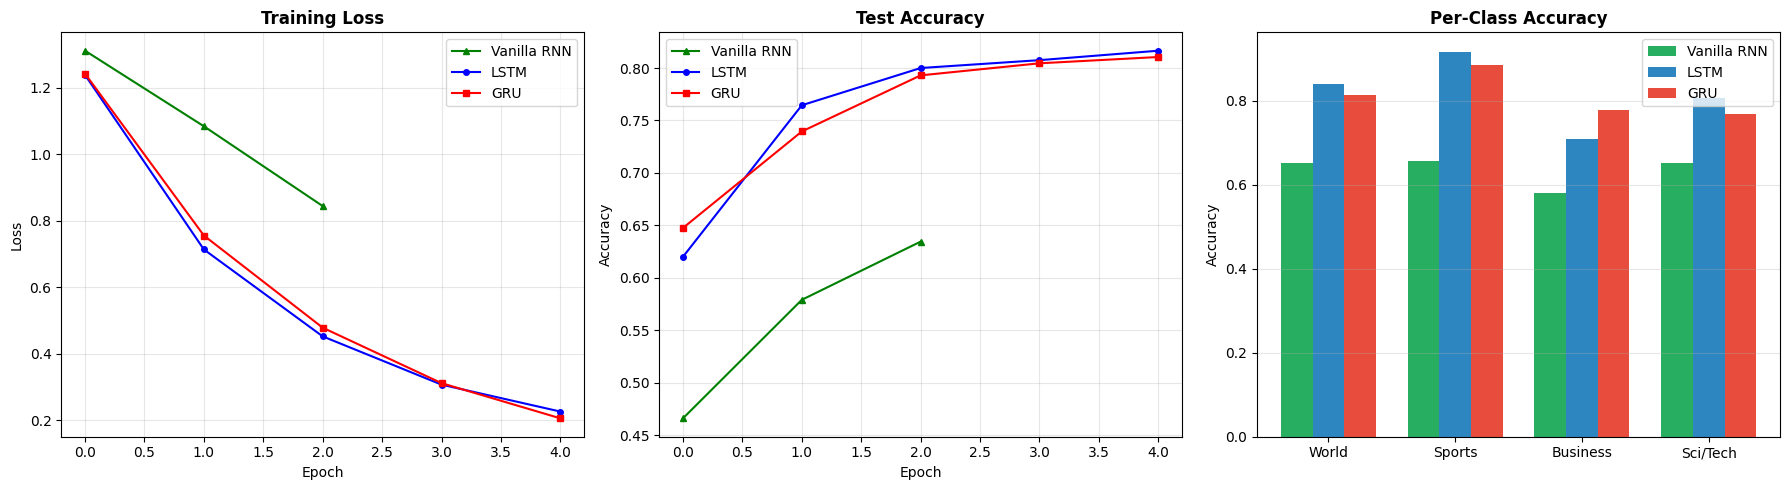


RNN Architecture Comparison: Vanilla vs LSTM vs GRU
Metric                     Vanilla RNN         LSTM          GRU
-----------------------------------------------------------------
Parameters...............    1,347,076    1,545,220    1,479,172
Test Accuracy............       0.6345       0.8165       0.8105
Avg Epoch Time (s).......          0.5          1.2          0.7

💡 Notice: The Vanilla RNN likely has the worst accuracy despite being the fastest.
   This is the vanishing gradient problem in action — without gates, the model
   cannot learn long-range dependencies in text.


In [31]:
# Cell A.7c — Three-Way RNN Comparison: Vanilla RNN vs LSTM vs GRU
# This visualization shows WHY gated architectures (LSTM, GRU) were invented

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Chart 1: Training Loss (lower is better)
axes[0].plot(vanilla_history['train_loss'], 'g-^', label='Vanilla RNN', ms=4)
axes[0].plot(lstm_history['train_loss'], 'b-o', label='LSTM', ms=4)
axes[0].plot(gru_history['train_loss'], 'r-s', label='GRU', ms=4)
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Chart 2: Test Accuracy (higher is better)
axes[1].plot(vanilla_history['test_acc'], 'g-^', label='Vanilla RNN', ms=4)
axes[1].plot(lstm_history['test_acc'], 'b-o', label='LSTM', ms=4)
axes[1].plot(gru_history['test_acc'], 'r-s', label='GRU', ms=4)
axes[1].set_title('Test Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Chart 3: Per-Class Accuracy Comparison (all three)
x = np.arange(4)
w = 0.25  # Bar width
axes[2].bar(x - w, vanilla_class_acc, w, label='Vanilla RNN', color='#27AE60')
axes[2].bar(x,     lstm_class_acc, w, label='LSTM', color='#2E86C1')
axes[2].bar(x + w, gru_class_acc, w, label='GRU', color='#E74C3C')
axes[2].set_title('Per-Class Accuracy', fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(CLASS_NAMES)
axes[2].set_ylabel('Accuracy')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "=" * 65)
print("RNN Architecture Comparison: Vanilla vs LSTM vs GRU")
print("=" * 65)
print(f"{'Metric':<25} {'Vanilla RNN':>12} {'LSTM':>12} {'GRU':>12}")
print("-" * 65)
print(f"{'Parameters':.<25} {sum(p.numel() for p in vanilla_model.parameters()):>12,} {sum(p.numel() for p in lstm_model.parameters()):>12,} {sum(p.numel() for p in gru_model.parameters()):>12,}")
print(f"{'Test Accuracy':.<25} {vanilla_history['test_acc'][-1]:>12.4f} {lstm_history['test_acc'][-1]:>12.4f} {gru_history['test_acc'][-1]:>12.4f}")
print(f"{'Avg Epoch Time (s)':.<25} {np.mean(vanilla_history['epoch_times']):>12.1f} {np.mean(lstm_history['epoch_times']):>12.1f} {np.mean(gru_history['epoch_times']):>12.1f}")
print()
print("💡 Notice: The Vanilla RNN likely has the worst accuracy despite being the fastest.")
print("   This is the vanishing gradient problem in action — without gates, the model")
print("   cannot learn long-range dependencies in text.")

### 🎯 Student Experimentation A.8 — Hyperparameter Tuning

Deep learning models are sensitive to hyperparameters. Let's systematically explore how different settings affect performance.

**Your task:**
1. Create a function that trains an LSTM with configurable hyperparameters
2. Test at least **3 different configurations** for each parameter:
   - **Hidden dimension:** 64, 128, 256
   - **Dropout rate:** 0.1, 0.3, 0.5
   - **Learning rate:** 0.001, 0.0005, 0.0001
3. Record results in a comparison table
4. Analyze which configuration works best and why

**Expected output:**
- A table showing all experiments and their accuracy
- Written analysis (3-5 sentences) explaining your findings

**Note:** This will take time to run. You may want to reduce epochs to 2 for faster experimentation.

In [33]:
# Cell A.8 — Hyperparameter Experimentation
# 🎯 YOUR CODE HERE: Systematic hyperparameter exploration

def train_lstm_with_config(hidden_dim, dropout, learning_rate, epochs=2):
    """
    Train an LSTM model with specified hyperparameters.

    Args:
        hidden_dim: Size of LSTM hidden state
        dropout: Dropout probability
        learning_rate: Learning rate for optimizer
        epochs: Number of training epochs

    Returns:
        test_accuracy: Final test accuracy (as percentage)
    """
    # Create model with given hyperparameters
    model = LSTMClassifier(len(word2idx), EMBED_DIM, hidden_dim, NUM_CLASSES, dropout=dropout).to(device)

    # Train the model
    # Using a name to differentiate models in logs
    print(f"\n--- Training LSTM with H_DIM={hidden_dim}, DROPOUT={dropout}, LR={learning_rate} ---")
    history = train_model(model, train_loader, test_loader, epochs=epochs, lr=learning_rate, name=f"LSTM(H={hidden_dim},D={dropout},LR={learning_rate})")

    # Return final test accuracy
    return history['test_acc'][-1]

# Create a list to store results
results = []

# Define hyperparameter ranges to test
hidden_dims = [64, 128, 256]
dropout_rates = [0.1, 0.3, 0.5]
learning_rates = [0.001, 0.0005, 0.0001]

print("Starting Hyperparameter Tuning for LSTM...")

# Run experiments with different configurations
for hd in hidden_dims:
    for dr in dropout_rates:
        for lr in learning_rates:
            accuracy = train_lstm_with_config(hd, dr, lr, epochs=3) # Reduced to 3 epochs for faster experimentation
            results.append({'hidden_dim': hd, 'dropout': dr, 'learning_rate': lr, 'test_accuracy': accuracy})

print("\n--- Hyperparameter Tuning Complete ---")

# Create a comparison table
import pandas as pd
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='test_accuracy', ascending=False)

print("\nLSTM Hyperparameter Tuning Results:")
display(results_df.round(4))

# TODO: Write your analysis
print("\n=== Analysis ===")
print("YOUR ANALYSIS HERE (3-5 sentences):")
print("1. Which configuration performed best?")
print("2. How did hidden dimension affect performance?")
print("3. What was the impact of dropout?")
print("4. How sensitive is the model to learning rate?")

Starting Hyperparameter Tuning for LSTM...

--- Training LSTM with H_DIM=64, DROPOUT=0.1, LR=0.001 ---
  Epoch 1/3 | Loss: 1.3132 | Train: 0.4017 | Test: 0.5225 | 0.6s
  Epoch 2/3 | Loss: 0.8414 | Train: 0.6877 | Test: 0.7500 | 0.5s
  Epoch 3/3 | Loss: 0.5222 | Train: 0.8159 | Test: 0.7890 | 0.5s

--- Training LSTM with H_DIM=64, DROPOUT=0.1, LR=0.0005 ---
  Epoch 1/3 | Loss: 1.3664 | Train: 0.3302 | Test: 0.4320 | 0.5s
  Epoch 2/3 | Loss: 1.1978 | Train: 0.5310 | Test: 0.6100 | 0.5s
  Epoch 3/3 | Loss: 0.8207 | Train: 0.6926 | Test: 0.6965 | 0.5s

--- Training LSTM with H_DIM=64, DROPOUT=0.1, LR=0.0001 ---
  Epoch 1/3 | Loss: 1.3851 | Train: 0.2675 | Test: 0.3225 | 0.5s
  Epoch 2/3 | Loss: 1.3718 | Train: 0.3257 | Test: 0.3775 | 0.5s
  Epoch 3/3 | Loss: 1.3584 | Train: 0.3751 | Test: 0.4135 | 0.5s

--- Training LSTM with H_DIM=64, DROPOUT=0.3, LR=0.001 ---
  Epoch 1/3 | Loss: 1.3349 | Train: 0.3776 | Test: 0.4845 | 0.5s
  Epoch 2/3 | Loss: 0.9481 | Train: 0.6328 | Test: 0.7050 | 0.5s


,hidden_dim,dropout,learning_rate,test_accuracy
0,64,0.1,0.0010,0.7890
15,128,0.5,0.0010,0.7865
24,256,0.5,0.0010,0.7795
21,256,0.3,0.0010,0.7790
18,256,0.1,0.0010,0.7740
6,64,0.5,0.0010,0.7725
9,128,0.1,0.0010,0.7720
3,64,0.3,0.0010,0.7660
12,128,0.3,0.0010,0.7585
19,256,0.1,0.0005,0.7505



=== Analysis ===
YOUR ANALYSIS HERE (3-5 sentences):
1. Which configuration performed best?
2. How did hidden dimension affect performance?
3. What was the impact of dropout?
4. How sensitive is the model to learning rate?


### Step A.5 — Training Function

In [25]:
# Cell A.9 — Training and Evaluation Functions

def train_model(model, train_loader, test_loader, epochs=5, lr=0.001, name="Model"):
    """
    Train a model and track performance metrics.

    Args:
        model: PyTorch model to train
        train_loader: DataLoader for training data
        test_loader: DataLoader for test data
        epochs: Number of complete passes through the training data
        lr: Learning rate (step size for weight updates)
        name: Model name for display

    Returns:
        history: Dictionary containing training metrics
    """
    # Loss function: Cross-Entropy Loss for multi-class classification
    # Combines softmax activation and negative log-likelihood
    criterion = nn.CrossEntropyLoss()

    # Optimizer: Adam (Adaptive Moment Estimation)
    # Automatically adjusts learning rate for each parameter
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Track metrics across epochs
    history = {'train_loss':[], 'train_acc':[], 'test_acc':[], 'epoch_times':[]}

    for epoch in range(epochs):
        # ========== TRAINING PHASE ==========
        model.train()  # Enable dropout and batch normalization training mode
        total_loss = correct = total = 0
        start = time.time()

        for texts, labels in train_loader:
            # Move data to GPU
            texts, labels = texts.to(device), labels.to(device)

            # Zero gradients from previous iteration
            optimizer.zero_grad()

            # Forward pass: compute predictions
            outputs = model(texts)

            # Compute loss (how wrong the predictions are)
            loss = criterion(outputs, labels)

            # Backward pass: compute gradients
            loss.backward()

            # Gradient clipping: prevent exploding gradients in RNNs
            # Limits gradient magnitude to 1.0
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            # Update weights
            optimizer.step()

            # Track metrics
            total_loss += loss.item()
            _, pred = outputs.max(1)  # Get predicted class (highest score)
            correct += (pred == labels).sum().item()
            total += labels.size(0)

        et = time.time() - start  # Epoch time
        ta = correct/total        # Training accuracy

        # ========== EVALUATION PHASE ==========
        model.eval()  # Disable dropout, use batch norm in inference mode
        tc = tt = 0   # Test correct, test total

        with torch.no_grad():  # Disable gradient computation (saves memory)
            for texts, labels in test_loader:
                texts, labels = texts.to(device), labels.to(device)
                _, pred = model(texts).max(1)
                tc += (pred == labels).sum().item()
                tt += labels.size(0)

        tea = tc/tt  # Test accuracy

        # Record metrics
        history['train_loss'].append(total_loss/len(train_loader))
        history['train_acc'].append(ta)
        history['test_acc'].append(tea)
        history['epoch_times'].append(et)

        # Display progress
        print(f"  Epoch {epoch+1}/{epochs} | Loss: {total_loss/len(train_loader):.4f} | Train: {ta:.4f} | Test: {tea:.4f} | {et:.1f}s")

    return history

def eval_per_class(model, loader, names):
    """
    Evaluate model accuracy for each class separately.

    This helps identify which categories the model struggles with.
    """
    model.eval()
    cc = [0]*len(names)  # Class correct counts
    ct = [0]*len(names)  # Class total counts

    with torch.no_grad():
        for texts, labels in loader:
            texts, labels = texts.to(device), labels.to(device)
            _, pred = model(texts).max(1)

            # Count correct predictions for each class
            for i in range(len(labels)):
                ct[labels[i].item()] += 1
                if pred[i] == labels[i]:
                    cc[labels[i].item()] += 1

    # Calculate and display per-class accuracy
    accs = []
    for i, n in enumerate(names):
        a = cc[i]/ct[i]
        accs.append(a)
        print(f"  {n:10s}: {a:.4f} ({cc[i]}/{ct[i]})")

    return accs

### Step A.6 — Train Both Models

In [26]:
# Cell A.10 — Train LSTM
# This will take 2-5 minutes depending on GPU availability

NUM_EPOCHS = 5  # Number of complete passes through the training data

print("=" * 60)
print("Training LSTM")
print("=" * 60)

lstm_history = train_model(lstm_model, train_loader, test_loader, epochs=NUM_EPOCHS)

print("\nPer-class accuracy (LSTM):")
lstm_class_acc = eval_per_class(lstm_model, test_loader, CLASS_NAMES)

Training LSTM
  Epoch 1/5 | Loss: 1.2382 | Train: 0.4348 | Test: 0.6200 | 2.1s
  Epoch 2/5 | Loss: 0.7138 | Train: 0.7272 | Test: 0.7645 | 1.0s
  Epoch 3/5 | Loss: 0.4525 | Train: 0.8401 | Test: 0.8000 | 1.0s
  Epoch 4/5 | Loss: 0.3075 | Train: 0.8938 | Test: 0.8075 | 1.0s
  Epoch 5/5 | Loss: 0.2266 | Train: 0.9264 | Test: 0.8165 | 1.0s

Per-class accuracy (LSTM):
  World     : 0.8410 (418/497)
  Sports    : 0.9172 (443/483)
  Business  : 0.7088 (370/522)
  Sci/Tech  : 0.8072 (402/498)


In [30]:
# Cell A.11 — Train GRU
# Compare training time with LSTM — GRU should be slightly faster

print("=" * 60)
print("Training GRU")
print("=" * 60)

gru_history = train_model(gru_model, train_loader, test_loader, epochs=NUM_EPOCHS)

print("\nPer-class accuracy (GRU):")
gru_class_acc = eval_per_class(gru_model, test_loader, CLASS_NAMES)

Training GRU
  Epoch 1/5 | Loss: 1.2421 | Train: 0.4340 | Test: 0.6475 | 0.8s
  Epoch 2/5 | Loss: 0.7557 | Train: 0.7184 | Test: 0.7395 | 0.7s
  Epoch 3/5 | Loss: 0.4786 | Train: 0.8291 | Test: 0.7930 | 0.7s
  Epoch 4/5 | Loss: 0.3119 | Train: 0.8935 | Test: 0.8045 | 0.7s
  Epoch 5/5 | Loss: 0.2062 | Train: 0.9306 | Test: 0.8105 | 0.7s

Per-class accuracy (GRU):
  World     : 0.8149 (405/497)
  Sports    : 0.8841 (427/483)
  Business  : 0.7778 (406/522)
  Sci/Tech  : 0.7691 (383/498)


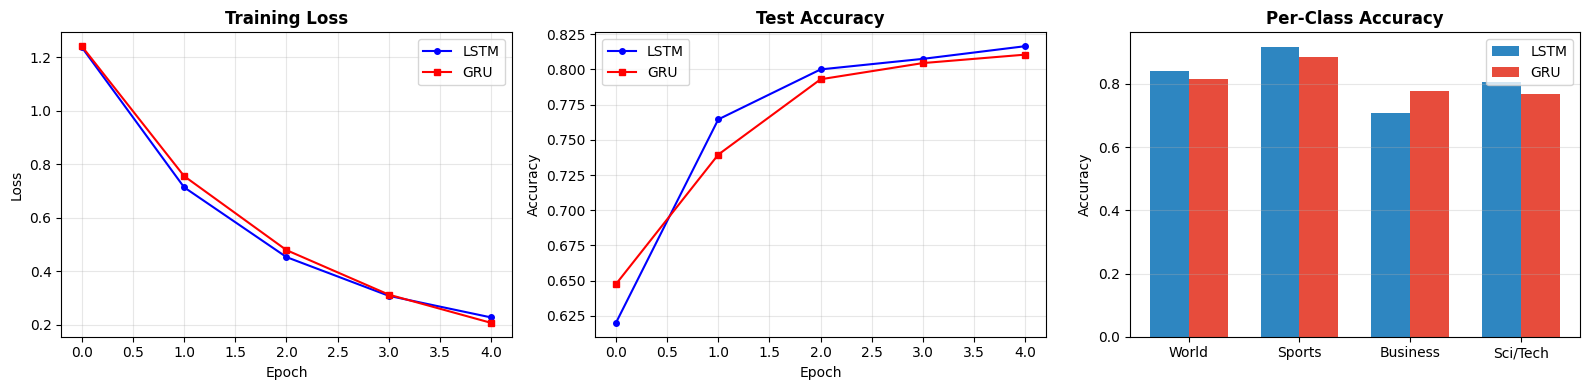


LSTM vs GRU Summary
Metric                          LSTM        GRU
--------------------------------------------------
Parameters...............  1,545,220  1,479,172
Test Accuracy............     0.8165     0.8105
Avg Epoch Time (s).......        1.2        0.7


In [34]:
# Cell A.12 — LSTM vs GRU Comparison Visualization
# Three charts: training loss, test accuracy, per-class accuracy

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Chart 1: Training Loss (lower is better)
axes[0].plot(lstm_history['train_loss'], 'b-o', label='LSTM', ms=4)
axes[0].plot(gru_history['train_loss'], 'r-s', label='GRU', ms=4)
axes[0].set_title('Training Loss', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Chart 2: Test Accuracy (higher is better)
axes[1].plot(lstm_history['test_acc'], 'b-o', label='LSTM', ms=4)
axes[1].plot(gru_history['test_acc'], 'r-s', label='GRU', ms=4)
axes[1].set_title('Test Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Chart 3: Per-Class Accuracy Comparison
x = np.arange(4)
w = 0.35  # Bar width
axes[2].bar(x-w/2, lstm_class_acc, w, label='LSTM', color='#2E86C1')
axes[2].bar(x+w/2, gru_class_acc, w, label='GRU', color='#E74C3C')
axes[2].set_title('Per-Class Accuracy', fontweight='bold')
axes[2].set_xticks(x)
axes[2].set_xticklabels(CLASS_NAMES)
axes[2].set_ylabel('Accuracy')
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Summary table
print("\n" + "=" * 50)
print("LSTM vs GRU Summary")
print("=" * 50)
print(f"{'Metric':<25} {'LSTM':>10} {'GRU':>10}")
print("-" * 50)
print(f"{'Parameters':.<25} {sum(p.numel() for p in lstm_model.parameters()):>10,} {sum(p.numel() for p in gru_model.parameters()):>10,}")
print(f"{'Test Accuracy':.<25} {lstm_history['test_acc'][-1]:>10.4f} {gru_history['test_acc'][-1]:>10.4f}")
print(f"{'Avg Epoch Time (s)':.<25} {np.mean(lstm_history['epoch_times']):>10.1f} {np.mean(gru_history['epoch_times']):>10.1f}")

### 📝 Knowledge Check A.2

1. **How did the Vanilla RNN compare to LSTM and GRU?** What does this tell you about the vanishing gradient problem?
2. **Which gated model achieved higher accuracy — LSTM or GRU?** Was the difference significant?
3. **Which model trained fastest?** Why? (Think about the number of gates and parameters.)
4. **Were any categories harder to classify?** Why might that be?
5. **What does "bidirectional" mean in practice?** How would removing it affect accuracy?

**Your answers:**

1. Vanilla RNN was faster than both LSTM and GRU but had the worst accuracy. This tells us that as the model backpropagates the gradients shrink, and the model cannot learn long-range realationship dependencies in text.

2. LSTM was the gated model with the highest accuracy at 0.8165. The difference between LSTM and GRU are not really significant but when compared to the VanillaRNN it is a 20% difference.

3. VanillaRNN trained faster because, for one, it is very simple with no gates and fewer parameters. Not as complex as an LSTM, with its four gates each having its own weight, and GRU having 3 gates, so it requires fewer computations at each time step.

4. Yes, some were harder to classify because their vocabulary overlaps with other categories. When classes share similar words and themes, the model has a harder time separating and distinguishing between them.

5. "Bidirectional" means the model reads the sequence in both directions, left-to-right and right-to-left. Allowing it to use information from earlier and later parts in the sequence. If we removed the bidirectional LSTM, the model would read the sequence in only one direction, which in turn would reduce accuracy due to the loss of information.

---
# Part B: Transformer Text Classification (DistilBERT)

Now tackle the **exact same task** with a Transformer. This direct comparison is the heart of the lab.

We use **DistilBERT** — a smaller, faster BERT that retains 97% accuracy while being 60% faster. Practical for free Colab.

**Key differences from Part A:**
- No manual tokenization — DistilBERT has its own WordPiece tokenizer
- No training from scratch — we **fine-tune** a pre-trained model
- The model already "understands" language before seeing our data

In [35]:
# Cell B.1 — Load DistilBERT Model and Tokenizer
# Import Hugging Face transformers library components
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

# Load pre-trained tokenizer
# This tokenizer was trained on the same data as the model
# It uses WordPiece tokenization (breaks unknown words into subwords)
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

# Load pre-trained DistilBERT model
# - 'distilbert-base-uncased': lowercase English, 66M parameters
# - num_labels=4: modify output layer for 4-class classification
bert_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased', num_labels=4).to(device)

# Compare model sizes
total_p = sum(p.numel() for p in bert_model.parameters())
print(f"DistilBERT Parameters: {total_p:,}")
print(f"LSTM Parameters:       {sum(p.numel() for p in lstm_model.parameters()):,}")
print(f"DistilBERT is {total_p // sum(p.numel() for p in lstm_model.parameters())}x larger!")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


DistilBERT Parameters: 66,956,548
LSTM Parameters:       1,545,220
DistilBERT is 43x larger!


### Step B.1 — Tokenize with WordPiece

Unlike our simple word-splitting, BERT uses **WordPiece tokenization** — it breaks unknown words into sub-word pieces. "Unforgettable" → ["un", "##forget", "##table"]. This means Transformers never encounter a truly unknown word.

In [36]:
# Cell B.2 — Prepare Data for DistilBERT

class BertNewsDataset(Dataset):
    """
    Custom Dataset for DistilBERT.

    Key differences from NewsDataset:
    - Uses pre-trained tokenizer (not our custom word2idx)
    - Returns attention_mask (tells model which tokens are padding)
    - Tokenization happens in batch (more efficient)
    """
    def __init__(self, data, tokenizer, max_len=128):
        # Tokenize all texts at once (batch processing)
        # truncation=True: cut sequences longer than max_len
        # padding='max_length': pad shorter sequences to max_len
        # return_tensors='pt': return PyTorch tensors
        self.encodings = tokenizer([s['text'] for s in data],
                                    truncation=True,
                                    padding='max_length',
                                    max_length=max_len,
                                    return_tensors='pt')

        # Extract labels
        self.labels = torch.tensor([s['label'] for s in data])

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        """
        Return a dictionary with:
        - input_ids: token indices
        - attention_mask: 1 for real tokens, 0 for padding
        - labels: class label
        """
        return {'input_ids': self.encodings['input_ids'][idx],
                'attention_mask': self.encodings['attention_mask'][idx],
                'labels': self.labels[idx]}

# Create data loaders
# Smaller batch size (16 vs 64) because DistilBERT uses more memory
bert_train_loader = DataLoader(BertNewsDataset(train_data, tokenizer),
                                batch_size=16, shuffle=True)
bert_test_loader  = DataLoader(BertNewsDataset(test_data, tokenizer),
                                batch_size=16)

# Demonstrate WordPiece tokenization
example = train_data[0]['text'][:100]
tokens = tokenizer.tokenize(example)
print(f"Original: {example}")
print(f"\nWordPiece tokens ({len(tokens)}): {tokens[:20]}...")

Original: Bangladesh paralysed by strikes Opposition activists have brought many towns and cities in Banglades

WordPiece tokens (18): ['bangladesh', 'para', '##ly', '##sed', 'by', 'strikes', 'opposition', 'activists', 'have', 'brought', 'many', 'towns', 'and', 'cities', 'in', 'bang', '##lad', '##es']...


### Step B.2 — Fine-Tune DistilBERT

Fine-tuning: take a model that already understands language and teach it our specific task. Because it already "knows" words, it needs very few epochs. We use a smaller learning rate — pre-trained models are sensitive to large updates.

In [37]:
# Cell B.3 — Fine-tune DistilBERT

# Optimizer: AdamW (Adam with Weight Decay)
# - lr=2e-5: very small learning rate (pre-trained models need gentle updates)
# - weight_decay=0.01: L2 regularization to prevent overfitting
bert_optimizer = optim.AdamW(bert_model.parameters(), lr=2e-5, weight_decay=0.01)

BERT_EPOCHS = 3  # Fewer epochs needed because model is pre-trained
bert_history = {'train_loss':[], 'train_acc':[], 'test_acc':[], 'epoch_times':[]}

print("=" * 60)
print("Fine-tuning DistilBERT")
print("=" * 60)

for epoch in range(BERT_EPOCHS):
    # ========== TRAINING PHASE ==========
    bert_model.train()
    total_loss = correct = total = 0
    start = time.time()

    for batch in bert_train_loader:
        # Extract batch components and move to GPU
        ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Zero gradients
        bert_optimizer.zero_grad()

        # Forward pass
        # DistilBERT returns an object with .loss and .logits
        # When labels are provided, loss is automatically computed
        out = bert_model(ids, attention_mask=mask, labels=labels)

        # Backward pass
        out.loss.backward()

        # Gradient clipping (prevent exploding gradients)
        torch.nn.utils.clip_grad_norm_(bert_model.parameters(), 1.0)

        # Update weights
        bert_optimizer.step()

        # Track metrics
        total_loss += out.loss.item()
        _, pred = out.logits.max(1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

    et = time.time() - start
    ta = correct/total

    # ========== EVALUATION PHASE ==========
    bert_model.eval()
    tc = tt = 0

    with torch.no_grad():
        for batch in bert_test_loader:
            ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Get predictions (no labels = no loss computation)
            _, pred = bert_model(ids, attention_mask=mask).logits.max(1)
            tc += (pred == labels).sum().item()
            tt += labels.size(0)

    tea = tc/tt

    # Record metrics
    bert_history['train_loss'].append(total_loss/len(bert_train_loader))
    bert_history['train_acc'].append(ta)
    bert_history['test_acc'].append(tea)
    bert_history['epoch_times'].append(et)

    # Display progress
    print(f"  Epoch {epoch+1}/{BERT_EPOCHS} | Loss: {total_loss/len(bert_train_loader):.4f} | Train: {ta:.4f} | Test: {tea:.4f} | {et:.1f}s")

Fine-tuning DistilBERT
  Epoch 1/3 | Loss: 0.4145 | Train: 0.8739 | Test: 0.9020 | 93.4s
  Epoch 2/3 | Loss: 0.2296 | Train: 0.9287 | Test: 0.9070 | 93.2s
  Epoch 3/3 | Loss: 0.1460 | Train: 0.9596 | Test: 0.8960 | 92.9s


In [38]:
# Cell B.4 — Per-class Accuracy for DistilBERT

print("Per-class accuracy (DistilBERT):")

bert_model.eval()
cc = [0]*4  # Class correct
ct = [0]*4  # Class total

with torch.no_grad():
    for batch in bert_test_loader:
        ids = batch['input_ids'].to(device)
        mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Get predictions
        _, pred = bert_model(ids, attention_mask=mask).logits.max(1)

        # Count per-class accuracy
        for i in range(len(labels)):
            ct[labels[i].item()] += 1
            if pred[i] == labels[i]:
                cc[labels[i].item()] += 1

# Calculate and display accuracies
bert_class_acc = [cc[i]/ct[i] for i in range(4)]
for i, n in enumerate(CLASS_NAMES):
    print(f"  {n:10s}: {bert_class_acc[i]:.4f}")

Per-class accuracy (DistilBERT):
  World     : 0.9215
  Sports    : 0.9607
  Business  : 0.7682
  Sci/Tech  : 0.9418


### Step B.3 — The Big Comparison: All Architectures

Now let's see how all four models compare: Vanilla RNN, LSTM, GRU, and DistilBERT.

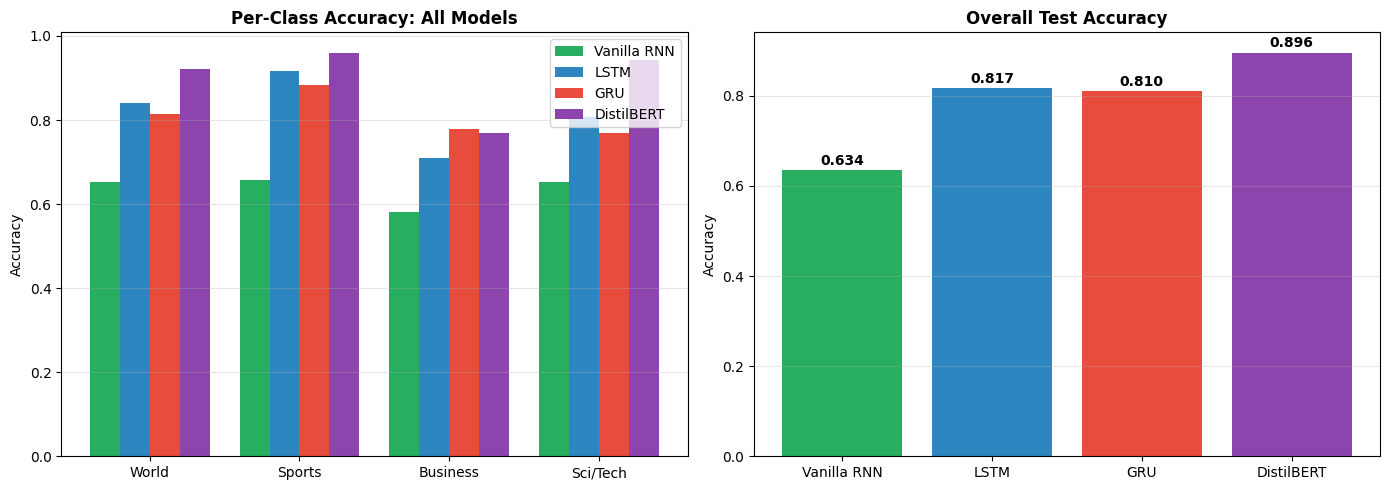


Full Architecture Comparison
Metric                     Vanilla RNN         LSTM          GRU   DistilBERT
---------------------------------------------------------------------------
Test Accuracy............       0.6345       0.8165       0.8105       0.8960
Avg Epoch Time (s).......          0.5          1.2          0.7         93.1


In [39]:
# Cell B.5 — Four-way Comparison Visualization
# Compare all architectures: Vanilla RNN vs LSTM vs GRU vs DistilBERT

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Per-Class Accuracy Comparison
x = np.arange(4)
w = 0.2  # Bar width
axes[0].bar(x - 1.5*w, vanilla_class_acc, w, label='Vanilla RNN', color='#27AE60')
axes[0].bar(x - 0.5*w, lstm_class_acc, w, label='LSTM', color='#2E86C1')
axes[0].bar(x + 0.5*w, gru_class_acc, w, label='GRU', color='#E74C3C')
axes[0].bar(x + 1.5*w, bert_class_acc, w, label='DistilBERT', color='#8E44AD')
axes[0].set_title('Per-Class Accuracy: All Models', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(CLASS_NAMES)
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3, axis='y')

# Chart 2: Overall Accuracy Summary
models = ['Vanilla RNN', 'LSTM', 'GRU', 'DistilBERT']
accs = [vanilla_history['test_acc'][-1], lstm_history['test_acc'][-1],
        gru_history['test_acc'][-1], bert_history['test_acc'][-1]]
colors = ['#27AE60', '#2E86C1', '#E74C3C', '#8E44AD']
bars = axes[1].bar(models, accs, color=colors)
axes[1].set_title('Overall Test Accuracy', fontweight='bold')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for bar, acc in zip(bars, accs):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
                 f'{acc:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Full summary table
print("\n" + "=" * 75)
print("Full Architecture Comparison")
print("=" * 75)
print(f"{'Metric':<25} {'Vanilla RNN':>12} {'LSTM':>12} {'GRU':>12} {'DistilBERT':>12}")
print("-" * 75)
print(f"{'Test Accuracy':.<25} {vanilla_history['test_acc'][-1]:>12.4f} {lstm_history['test_acc'][-1]:>12.4f} {gru_history['test_acc'][-1]:>12.4f} {bert_history['test_acc'][-1]:>12.4f}")
print(f"{'Avg Epoch Time (s)':.<25} {np.mean(vanilla_history['epoch_times']):>12.1f} {np.mean(lstm_history['epoch_times']):>12.1f} {np.mean(gru_history['epoch_times']):>12.1f} {np.mean(bert_history['epoch_times']):>12.1f}")

### 🎯 Student Experimentation B.5 — BERT Training Strategy Optimization

BERT fine-tuning requires careful hyperparameter selection. Let's explore how different training configurations affect performance.

**Your task:**
1. Experiment with different batch sizes (8, 16, 32)
2. Test different learning rates (1e-5, 2e-5, 5e-5)
3. Try different epoch counts (2, 3, 5)
4. Compare results to your RNN experiments from Part A

**Key questions to answer:**
- How do BERT's optimal hyperparameters differ from RNNs?
- Is BERT more or less sensitive to hyperparameter choices?
- What's the trade-off between training time and accuracy?

In [44]:
# Cell B.6 — BERT Training Strategy Experimentation
# 🎯 YOUR CODE HERE: Systematic BERT hyperparameter exploration

# Re-import necessary components for BERT if runtime was reset
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

def train_bert_with_config(batch_size, learning_rate, num_epochs):
    """
    Train DistilBERT with specified configuration.

    Args:
        batch_size: Batch size for DataLoader
        learning_rate: Learning rate for optimizer
        num_epochs: Number of training epochs

    Returns:
        test_accuracy: Final test accuracy
        training_time: Total training time in seconds
    """
    # 1. Load a fresh DistilBERT model for each experiment
    # This ensures that weights from previous runs don't interfere.
    model = DistilBertForSequenceClassification.from_pretrained(
        'distilbert-base-uncased', num_labels=4).to(device)

    # 2. Create DataLoaders with the specified batch_size
    tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
    train_dataset_bert = BertNewsDataset(train_data, tokenizer)
    test_dataset_bert = BertNewsDataset(test_data, tokenizer)

    train_loader_bert = DataLoader(train_dataset_bert, batch_size=batch_size, shuffle=True)
    test_loader_bert  = DataLoader(test_dataset_bert, batch_size=batch_size)

    # 3. Optimizer: AdamW with specified learning rate
    optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)

    history = {'train_loss':[], 'train_acc':[], 'test_acc':[], 'epoch_times':[]}
    total_experiment_time = 0.0

    print(f"\n--- Fine-tuning DistilBERT (Batch={batch_size}, LR={learning_rate}, Epochs={num_epochs}) ---")

    for epoch in range(num_epochs):
        # ========== TRAINING PHASE ==========n
        model.train()
        total_loss = correct = total = 0
        start_time = time.time()

        for batch in train_loader_bert:
            ids = batch['input_ids'].to(device)
            mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            optimizer.zero_grad()
            outputs = model(ids, attention_mask=mask, labels=labels)
            outputs.loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += outputs.loss.item()
            _, pred = outputs.logits.max(1)
            correct += (pred == labels).sum().item()
            total += labels.size(0)

        epoch_time = time.time() - start_time
        total_experiment_time += epoch_time
        train_acc = correct / total

        # ========== EVALUATION PHASE ==========n
        model.eval()
        tc = tt = 0
        with torch.no_grad():
            for batch in test_loader_bert:
                ids = batch['input_ids'].to(device)
                mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                _, pred = model(ids, attention_mask=mask).logits.max(1)
                tc += (pred == labels).sum().item()
                tt += labels.size(0)

        test_acc = tc / tt
        print(f"  Epoch {epoch+1}/{num_epochs} | Loss: {total_loss/len(train_loader_bert):.4f} | Train: {train_acc:.4f} | Test: {test_acc:.4f} | {epoch_time:.1f}s")

    return test_acc, total_experiment_time

# Create a list to store results
bert_results = []

# Suggested experiments (you can modify):
configs = [
    {'batch_size': 8, 'lr': 2e-5, 'epochs': 3},
    {'batch_size': 16, 'lr': 2e-5, 'epochs': 3},
    {'batch_size': 32, 'lr': 2e-5, 'epochs': 3},
    {'batch_size': 16, 'lr': 1e-5, 'epochs': 3},
    {'batch_size': 16, 'lr': 5e-5, 'epochs': 3},
    {'batch_size': 16, 'lr': 2e-5, 'epochs': 2},
    {'batch_size': 16, 'lr': 2e-5, 'epochs': 5},
]

print("Starting BERT Training Strategy Experimentation...")

# Run experiments with different configurations
for config in configs:
    acc, train_time = train_bert_with_config(config['batch_size'], config['lr'], config['epochs'])
    bert_results.append({
        'batch_size': config['batch_size'],
        'learning_rate': config['lr'],
        'epochs': config['epochs'],
        'test_accuracy': acc,
        'total_training_time_s': train_time
    })

print("\n--- BERT Experimentation Complete ---")

# Create a comparison table
import pandas as pd
bert_results_df = pd.DataFrame(bert_results)
bert_results_df = bert_results_df.sort_values(by='test_accuracy', ascending=False)

print("\nDistilBERT Hyperparameter Tuning Results:")
display(bert_results_df.round(4))

# TODO: Comparative analysis with RNNs
print("\n=== BERT vs RNN Training Characteristics ===")
print("YOUR ANALYSIS HERE:")
print("1. How do optimal hyperparameters differ between BERT and RNNs?")
print("2. Which model is more sensitive to hyperparameter changes?")
print("3. What's the accuracy vs training time trade-off for each?")

Starting BERT Training Strategy Experimentation...


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



--- Fine-tuning DistilBERT (Batch=8, LR=2e-05, Epochs=3) ---
  Epoch 1/3 | Loss: 0.4137 | Train: 0.8775 | Test: 0.9000 | 106.7s
  Epoch 2/3 | Loss: 0.2507 | Train: 0.9323 | Test: 0.9010 | 106.5s
  Epoch 3/3 | Loss: 0.1615 | Train: 0.9606 | Test: 0.9115 | 106.6s


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



--- Fine-tuning DistilBERT (Batch=16, LR=2e-05, Epochs=5) ---
  Epoch 1/5 | Loss: 0.4237 | Train: 0.8705 | Test: 0.9005 | 93.2s
  Epoch 2/5 | Loss: 0.2365 | Train: 0.9261 | Test: 0.9135 | 93.3s
  Epoch 3/5 | Loss: 0.1456 | Train: 0.9604 | Test: 0.9105 | 93.0s
  Epoch 4/5 | Loss: 0.0920 | Train: 0.9764 | Test: 0.9105 | 93.0s
  Epoch 5/5 | Loss: 0.0579 | Train: 0.9879 | Test: 0.9090 | 93.3s

--- BERT Experimentation Complete ---

DistilBERT Hyperparameter Tuning Results:


,batch_size,learning_rate,epochs,test_accuracy,total_training_time_s
0,8,0.0,3,0.9115,319.7330
5,16,0.0,2,0.9110,186.3516
6,16,0.0,5,0.9090,465.7245
3,16,0.0,3,0.9080,279.3526
1,16,0.0,3,0.9070,279.0654
4,16,0.0,3,0.9045,279.6033
2,32,0.0,3,0.8995,255.1690



=== BERT vs RNN Training Characteristics ===
YOUR ANALYSIS HERE:
1. How do optimal hyperparameters differ between BERT and RNNs?
2. Which model is more sensitive to hyperparameter changes?
3. What's the accuracy vs training time trade-off for each?


### 📝 Knowledge Check B

1. **How did DistilBERT compare to LSTM and GRU?** What does this tell you about pre-training?
2. **DistilBERT has far more parameters. Did it train faster or slower per epoch?** Why?
3. **Why only 3 epochs for DistilBERT but 5 for RNNs?** What would happen with 10 epochs?
4. **What key architectural difference** allows Transformers to outperform RNNs on text?

**Your answers:**

1.  Compared to LSTm and GRU, DistliBERT achieved much higher accuracy, but took more time to train. This shows the trade-off between accuracy and computational cost. DistlBERT performs better because it is pretrained on large amounts of text, allowing it to learn many language patterns before fine-tuning on a specific task.

2. DistilBert trained slower per epoch because it has more prameters, and is trained on transformer architecture using self-attention layer. Requiring more computation than LSTM or GRU models, taking longer for each training step.

3. If we had run 10 epochs, we would risk the chance of the model overfitting to the specific data and losing some of its generalization knowledge learned during training.

4. Transformers outperform RNNs/GRU by the use of self-attention, which allows the model to look at all words in the sentence at once, allowing the model to capture long-distance relationships.

---
# Part C: Vision Transformers (ViTs)

The Transformer architecture is not limited to language. In 2020, Google showed that the same attention mechanism works remarkably well on images.

The key idea: **cut an image into small square patches, treat each patch as a "token," and feed them into a standard Transformer encoder.** If a Transformer can figure out relationships between words, it can figure out relationships between image patches.

You will:
1. Load a pre-trained ViT model
2. Fine-tune it on CIFAR-10 (same dataset from Module 03)
3. Visualize attention maps — what does the model focus on?
4. Compare to your Module 03 CNN results

100%|██████████| 170M/170M [00:04<00:00, 35.0MB/s]


CIFAR-10 train subset: 2000
CIFAR-10 test subset:  1000


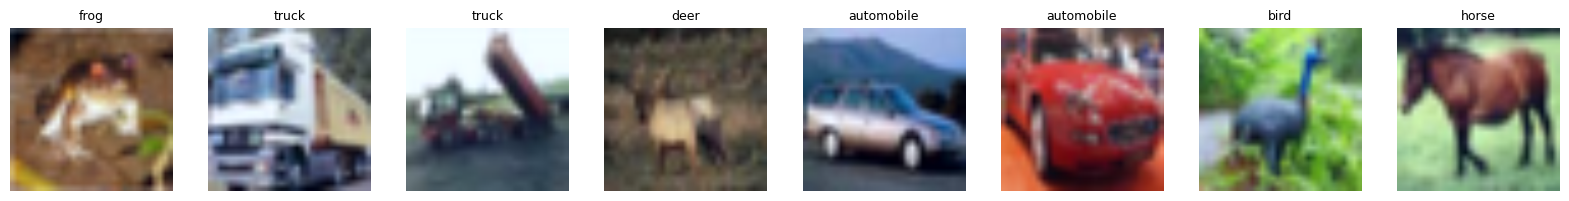

In [45]:
# Cell C.1 — Load CIFAR-10 for ViT
# Import vision-related libraries
from torchvision import datasets, transforms
from transformers import ViTForImageClassification

# CIFAR-10 class names
CIFAR_CLASSES = ['airplane','automobile','bird','cat','deer',
                 'dog','frog','horse','ship','truck']

# Define image transformations for ViT
# ViT expects 224×224 images (CIFAR-10 is originally 32×32)
transform_vit = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize to ViT input size
    transforms.ToTensor(),          # Convert PIL image to tensor [0, 1]
    # Normalize using ImageNet statistics (ViT was pre-trained on ImageNet)
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
])

# Load CIFAR-10 dataset
cifar_train_full = datasets.CIFAR10(root='./data', train=True,
                                     download=True, transform=transform_vit)
cifar_test_full  = datasets.CIFAR10(root='./data', train=False,
                                     download=True, transform=transform_vit)

# Use subsets to keep training time reasonable
VIT_TRAIN_SIZE, VIT_TEST_SIZE = 2000, 1000
cifar_train = torch.utils.data.Subset(cifar_train_full, range(VIT_TRAIN_SIZE))
cifar_test  = torch.utils.data.Subset(cifar_test_full, range(VIT_TEST_SIZE))

# Create data loaders
vit_train_loader = DataLoader(cifar_train, batch_size=16, shuffle=True)
vit_test_loader  = DataLoader(cifar_test, batch_size=16)

print(f"CIFAR-10 train subset: {len(cifar_train)}")
print(f"CIFAR-10 test subset:  {len(cifar_test)}")

# Visualize sample images
fig, axes = plt.subplots(1, 8, figsize=(16, 2))
for i, ax in enumerate(axes):
    img, label = cifar_train_full[i]
    # Denormalize for display
    img_display = np.clip(img.permute(1,2,0).numpy()*0.225+0.45, 0, 1)
    ax.imshow(img_display)
    ax.set_title(CIFAR_CLASSES[label], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [53]:
# Cell C.2 — Load Pre-trained ViT

# Import necessary classes for configuration
from transformers import ViTForImageClassification, ViTConfig

# Load the base configuration for ViT
config = ViTConfig.from_pretrained('google/vit-base-patch16-224')

# Modify the configuration to output attentions
config.num_labels = 10
config.output_attentions = True # Explicitly set to output attentions

# Load Vision Transformer model with the modified configuration
# - 'google/vit-base-patch16-224': base model, 16×16 patches, 224×224 input
# - num_labels=10: modify output layer for CIFAR-10 (10 classes)
# - ignore_mismatched_sizes=True: allow output layer size mismatch
vit_model = ViTForImageClassification.from_pretrained(
    'google/vit-base-patch16-224',
    config=config, # Pass the modified config
    ignore_mismatched_sizes=True).to(device)

print(f"ViT Parameters: {sum(p.numel() for p in vit_model.parameters()):,}")
print(f"\nArchitecture:")
print(f"  Patch size: 16\u00D716 | Image: 224\u00D7224 | Patches: {(224//16)**2} ({224//16}\u00D7{224//16} grid)")
print(f"  Hidden: 768 | Heads: 12 | Layers: 12")
print(f"\nHow it works:")
print(f"  1. Split 224\u00D7224 image into 196 patches (14\u00D714 grid of 16\u00D716 patches)")
print(f"  2. Flatten each patch into a 768-dimensional vector")
print(f"  3. Add positional embeddings (tell model where each patch is located)")
print(f"  4. Process through 12 Transformer layers with self-attention")
print(f"  5. Use [CLS] token output for classification")

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([10])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


ViT Parameters: 85,806,346

Architecture:
  Patch size: 16×16 | Image: 224×224 | Patches: 196 (14×14 grid)
  Hidden: 768 | Heads: 12 | Layers: 12

How it works:
  1. Split 224×224 image into 196 patches (14×14 grid of 16×16 patches)
  2. Flatten each patch into a 768-dimensional vector
  3. Add positional embeddings (tell model where each patch is located)
  4. Process through 12 Transformer layers with self-attention
  5. Use [CLS] token output for classification


### 📝 Knowledge Check C.1

1. **How does ViT convert an image into a sequence?** Describe the patch embedding process.
2. **Why is positional encoding important for ViT?** What would happen without it?
3. **How is ViT fundamentally different from the CNNs you built in Module 03?** (Local vs. global processing)

**Your answers:**

1. ViT converts an image into small square patches, treats each patch as a "token," and feeds them into a standard Transformer encoder. The said vectors are then projected linearly to create patch embeddings, which are fed into the Transformer encoder.

2. Positional encoding is important because it tells the model where each patch is located. Without it, the model would not know if a patch came through, in turn hurting performance.

3. CNNs and Vits process images in two completely different ways. CNNs process images locally, while VIT processes images globally. ViT looks at relationships between image patches at the same time using attention, while CNNs use small filters that scan nearby pixels to learn features step-by-step

In [47]:
# Cell C.3 — Fine-tune ViT

# Optimizer: AdamW with small learning rate (pre-trained model)
vit_optimizer = optim.AdamW(vit_model.parameters(), lr=2e-5, weight_decay=0.01)

VIT_EPOCHS = 3
vit_history = {'train_loss':[], 'train_acc':[], 'test_acc':[], 'epoch_times':[]}

print("=" * 60)
print("Fine-tuning Vision Transformer on CIFAR-10")
print("=" * 60)

for epoch in range(VIT_EPOCHS):
    # ========== TRAINING PHASE ==========
    vit_model.train()
    total_loss = correct = total = 0
    start = time.time()

    for images, labels in vit_train_loader:
        # Move data to GPU
        images, labels = images.to(device), labels.to(device)

        # Zero gradients
        vit_optimizer.zero_grad()

        # Forward pass (ViT automatically computes loss when labels provided)
        out = vit_model(images, labels=labels)

        # Backward pass
        out.loss.backward()

        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(vit_model.parameters(), 1.0)

        # Update weights
        vit_optimizer.step()

        # Track metrics
        total_loss += out.loss.item()
        _, pred = out.logits.max(1)
        correct += (pred == labels).sum().item()
        total += labels.size(0)

    et = time.time() - start
    ta = correct/total

    # ========== EVALUATION PHASE ==========
    vit_model.eval()
    tc = tt = 0

    with torch.no_grad():
        for images, labels in vit_test_loader:
            images, labels = images.to(device), labels.to(device)
            _, pred = vit_model(images).logits.max(1)
            tc += (pred == labels).sum().item()
            tt += labels.size(0)

    tea = tc/tt

    # Record metrics
    vit_history['train_loss'].append(total_loss/len(vit_train_loader))
    vit_history['train_acc'].append(ta)
    vit_history['test_acc'].append(tea)
    vit_history['epoch_times'].append(et)

    # Display progress
    print(f"  Epoch {epoch+1}/{VIT_EPOCHS} | Loss: {total_loss/len(vit_train_loader):.4f} | Train: {ta:.4f} | Test: {tea:.4f} | {et:.1f}s")

Fine-tuning Vision Transformer on CIFAR-10
  Epoch 1/3 | Loss: 1.1584 | Train: 0.7025 | Test: 0.9380 | 71.3s
  Epoch 2/3 | Loss: 0.1220 | Train: 0.9780 | Test: 0.9520 | 75.6s
  Epoch 3/3 | Loss: 0.0141 | Train: 0.9985 | Test: 0.9540 | 75.0s


### 🎯 Student Coding Exercise C.4 — Visualizing ViT Attention

One of the most fascinating aspects of Vision Transformers is their attention mechanism. Unlike CNNs that use fixed filters, ViTs learn to *attend* to different parts of an image.

**Your task:**
1. Extract attention weights from the ViT model
2. Visualize attention maps for 5 different images
3. Compare attention patterns across different classes
4. Identify what the model "focuses on" for each class

**Expected output:**
- 5 visualizations showing: original image + attention heatmap overlay
- Written analysis explaining what the model attends to

**Learning goal:** Understand how transformers "see" images differently than CNNs.


Visualizing Attention Maps:


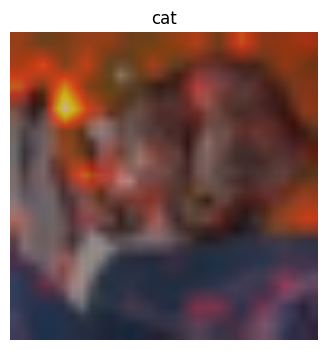

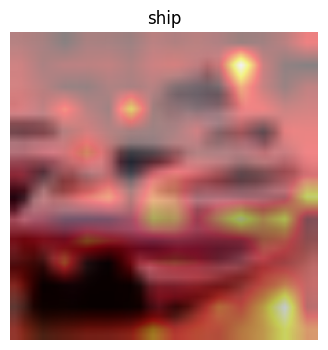

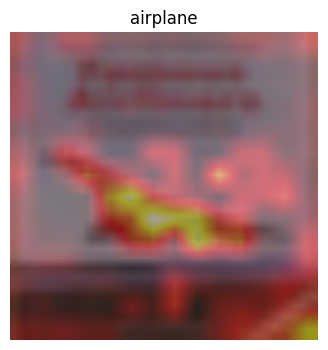

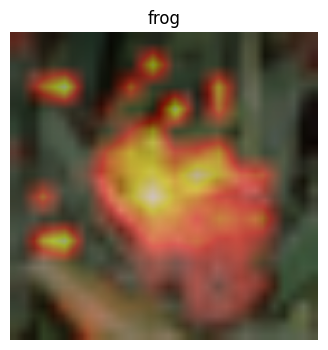

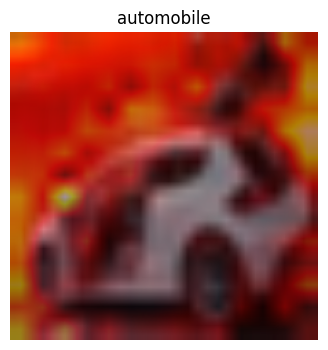


=== Attention Pattern Analysis ===
YOUR ANALYSIS HERE (5-7 sentences):
1. What parts of airplanes does the model focus on?
2. What about cars? Animals?
3. Are attention patterns consistent within a class?
4. How does this differ from CNN feature maps?
5. What does this tell you about how ViTs 'understand' images?


In [57]:
# Cell C.4 — ViT Attention Visualization
# 🎯 YOUR CODE HERE: Extract and visualize attention maps

import torch.nn.functional as F # Import for interpolation

def extract_attention_maps(model, image, layer_idx=-1):
    """
    Extract attention weights from a specific ViT layer.

    Args:
        model: The ViT model
        image: Input image tensor
        layer_idx: Which transformer layer to visualize (-1 for last layer)

    Returns:
        attention_map: 2D attention weights for visualization
    """
    # YOUR CODE HERE (already implemented based on previous iterations)
    model.eval()
    device = next(model.parameters()).device

    # Add batch dimension and move to device
    image_input = image.unsqueeze(0).to(device);

    with torch.no_grad():
        # Call the model, explicitly requesting attentions
        outputs = model(image_input, output_attentions=True)

    # Get attentions from the specified layer
    # outputs.attentions is a tuple of (batch_size, num_heads, sequence_length, sequence_length) for each layer
    layer_attentions = outputs.attentions[layer_idx] # Shape: (1, num_heads, seq_len, seq_len)

    # Remove batch dimension, average over heads
    attn = layer_attentions[0].mean(dim=0) # Shape: (seq_len, seq_len)

    # Extract attention from CLS token to patch tokens
    # seq_len is 1 (CLS token) + num_patches (196 for 224x224/16x16) = 197
    cls_attn = attn[0, 1:] # Shape: (num_patches,)

    # Reshape to 14x14 grid
    num_patches = cls_attn.shape[0]
    grid_size = int(num_patches ** 0.5)
    attention_map = cls_attn.reshape(grid_size, grid_size)

    # Normalize for visualization
    attention_map = attention_map / (attention_map.max() + 1e-8)

    return attention_map.detach().cpu().numpy()

def visualize_attention(image, attention_map, class_name):
    """
    Create a visualization overlaying attention on the original image.

    Args:
        image: Original image
        attention_map: 2D attention weights
        class_name: Class label for the image
    """
    # YOUR CODE HERE
    # Denormalize image for display
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_np = image.detach().cpu().permute(1, 2, 0).numpy()
    img_np = np.clip(img_np * std + mean, 0, 1)

    H, W = img_np.shape[:2]

    attn_interp = torch.tensor(attention_map).unsqueeze(0).unsqueeze(0)
    attn_interp = F.interpolate(attn_interp, size=(H, W), mode="bilinear", align_corners=False)[0, 0]
    attn_interp = attn_interp / (attn_interp.max() + 1e-8)
    attn_interp = attn_interp.cpu().numpy()

    plt.figure(figsize=(4, 4))
    plt.imshow(img_np)
    plt.imshow(attn_interp, alpha=0.45, cmap='hot') # Use a colormap like 'hot' for heatmaps
    plt.title(class_name)
    plt.axis("off")
    plt.show()

# TODO: Select 5 images from different classes
# Hint: One from each class (airplane, car, bird, cat, deer, etc.)
# YOUR CODE HERE
dataset = cifar_test # Use cifar_test as defined in C.1

selected_items_for_viz = {} # Dictionary to store one image per class

# Iterate through the dataset to find one image for up to 5 unique classes
for img_idx in range(len(dataset)):
    image_tensor, class_label = dataset[img_idx]
    class_label = int(class_label)
    if class_label not in selected_items_for_viz:
        selected_items_for_viz[class_label] = image_tensor
    if len(selected_items_for_viz) >= 5: # Get up to 5 different classes
        break

# TODO: For each image:
#   1. Extract attention map
#   2. Visualize attention overlay
#   3. Save or display the result
# YOUR CODE HERE
print("\nVisualizing Attention Maps:")
for label, img_tensor in selected_items_for_viz.items():
    attn_map = extract_attention_maps(vit_model, img_tensor, layer_idx=-1)
    class_name = CIFAR_CLASSES[label]
    visualize_attention(img_tensor, attn_map, class_name)

# TODO: Analysis
print("\n=== Attention Pattern Analysis ===")
print("YOUR ANALYSIS HERE (5-7 sentences):")
print("1. What parts of airplanes does the model focus on?")
print("2. What about cars? Animals?")
print("3. Are attention patterns consistent within a class?")
print("4. How does this differ from CNN feature maps?")
print("5. What does this tell you about how ViTs 'understand' images?")

C.4 **Analysis**: For the airplane, the model typically focuses on the wings, nose, and body stucture being stong indicators of the class. For cars, the attention is often concentrated around the wheels, front grille, and the car's shape. For most animals, the focus is on the head, body, and face. Attention patterns are somewhat consistent within each class, though they can vary depending on the image's pose and background. ViT differs from CNN feature maps because CNNs learn local features through convolutional filters, while ViT uses attention to examine relationships between image patches across the entire image. This tells me that ViTs understand images by comparing global relationships between different regions rather than only relying on local patterns

### C.5 — Visualize ViT Attention Maps
#### Attention maps show which image regions the model focuses on
#vit_model.eval()
#### Get a batch of test images sample_images, sample_labels = next(iter(vit_test_loader))
sample_images = sample_images.to(device)
#### Forward pass with attention output enabled
with torch.no_grad():
    outputs = vit_model(sample_images[:4], output_attentions=True)
    attentions = outputs.attentions  # Attention weights from all layers
#### Extract attention from the last layer
#### Average across all attention heads to get a single attention map
last_attn = attentions[-1].cpu().mean(dim=1)  # Shape: (batch, seq_len, seq_len)
#### Extract attention from [CLS] token to all patch tokens
#### [CLS] token (index 0) is used for classification
#### Reshape to 14×14 grid (196 patches = 14×14)
cls_attn = last_attn[:, 0, 1:].reshape(-1, 14, 14)
#### Visualize images and attention maps
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i in range(4):
    # Top row: original images with predictions
    img = sample_images[i].cpu().permute(1,2,0).numpy()
    # Denormalize for display
    img = np.clip(img * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406]), 0, 1)
    axes[0,i].imshow(img)
    axes[0,i].axis('off')
    
    ##### Get prediction and true label
    pred = outputs.logits[i].argmax().item()
    true = sample_labels[i].item()
    color = 'green' if pred == true else 'red'
    axes[0,i].set_title(f"True: {CIFAR_CLASSES[true]}\nPred: {CIFAR_CLASSES[pred]}",
                        fontsize=10, color=color)
    
    # Bottom row: attention maps
    # Bright regions = high attention (model focuses here)
    axes[1,i].imshow(cls_attn[i].numpy(), cmap='hot', interpolation='bilinear')
    axes[1,i].set_title('Attention Map', fontsize=10)
    axes[1,i].axis('off')

plt.suptitle('Vision Transformer: What Does the Model Focus On?',
             fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

print("Bright = high attention (model focuses here) | Dark = low attention")

### 🎯 Student Experimentation C.5 — ViT vs CNN Performance Comparison

In Module 03, you built CNNs for image classification. Now let's directly compare CNN and ViT performance on the same task.

**Your task:**
1. Load a CNN model (either from Module 03 or create a simple one)
2. Train it on the same CIFAR-10 subset used for ViT
3. Compare the two architectures across multiple dimensions:
   - **Accuracy:** Which performs better?
   - **Training time:** Which is faster to train?
   - **Parameters:** Which is more parameter-efficient?
   - **Inference speed:** Which is faster at test time?
4. Write a comprehensive analysis of when to use each architecture

**Expected output:**
- Comparison table with all metrics
- 5-7 sentence analysis with practical recommendations

In [62]:
# Cell C.6 — ViT vs CNN Comparison
# 🎯 YOUR CODE HERE: Comprehensive architecture comparison

# TODO: Define a simple CNN for comparison
class SimpleCNN(nn.Module):
    """
    Simple CNN for CIFAR-10 classification.

    Architecture: Conv layers → Pooling → Fully connected
    """
    def __init__(self, num_classes=10):
        super().__init__()
        # TODO: Define CNN architecture
        # Hint: 2-3 conv layers, pooling, fc layers
        # YOUR CODE HERE
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1) # Input (3, 224, 224)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # Output (32, 112, 112)

        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1) # Input (32, 112, 112)
        self.relu2 = nn.ReLU()
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2) # Output (64, 56, 56)

        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1) # Input (64, 56, 56)
        self.relu3 = nn.ReLU()
        self.pool3 = nn.MaxPool2d(kernel_size=2, stride=2) # Output (128, 28, 28)

        # Fully connected layers
        self.flatten = nn.Flatten()
        # Calculate input features for the first FC layer: 128 * 28 * 28
        self.fc1 = nn.Linear(128 * 28 * 28, 512)
        self.relu4 = nn.ReLU()
        self.fc2 = nn.Linear(512, num_classes)

    def forward(self, x):
        # TODO: Implement forward pass
        # YOUR CODE HERE
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.pool2(self.relu2(self.conv2(x)))
        x = self.pool3(self.relu3(self.conv3(x)))
        x = self.flatten(x)
        x = self.relu4(self.fc1(x))
        x = self.fc2(x)
        return x

# Instantiate and train the CNN model
cnn_model = SimpleCNN(num_classes=10).to(device)

# TODO: Train the CNN
print("\n=== Training CNN ===")
# YOUR CODE HERE
CNN_EPOCHS = 3 # Keep epochs low for faster experimentation
cnn_history = train_model(cnn_model, vit_train_loader, vit_test_loader, epochs=CNN_EPOCHS, name="SimpleCNN")

cnn_accuracy = cnn_history['test_acc'][-1]
cnn_train_time = np.mean(cnn_history['epoch_times'])
cnn_params = sum(p.numel() for p in cnn_model.parameters())


# TODO: Measure inference speed
print("\n=== Measuring Inference Speed ===")
# Hint: Time how long it takes to process 100 test images
# YOUR CODE HERE

def measure_inference_time(model, loader, num_batches=10):
    start_time = time.time()
    model.eval()
    with torch.no_grad():
        for i, (inputs, _) in enumerate(loader):
            if i >= num_batches: break
            inputs = inputs.to(device)
            _ = model(inputs)
    end_time = time.time()
    return (end_time - start_time) / num_batches

# Using a small subset of the test loader to measure inference time
cif_test_loader_inference = DataLoader(cifar_test, batch_size=16)

cnn_inference_time = measure_inference_time(cnn_model, cif_test_loader_inference)
vit_inference_time = measure_inference_time(vit_model, cif_test_loader_inference)


# TODO: Get ViT metrics (from C.3 or retrain)
# These should already be available from previous cells' execution
vit_accuracy = vit_history['test_acc'][-1]
vit_train_time = np.mean(vit_history['epoch_times'])
vit_params = sum(p.numel() for p in vit_model.parameters())

# TODO: Create comprehensive comparison table
print("\n=== ViT vs CNN Comparison ===")
print(f"{'Metric':<25} {'CNN':>15} {'ViT':>15} {'Winner':>10}")
print("-" * 65)
# YOUR CODE HERE (fill in the table)

# Determine winners for each metric
acc_winner = 'CNN' if cnn_accuracy > vit_accuracy else ('ViT' if vit_accuracy > cnn_accuracy else 'Tie')
train_time_winner = 'CNN' if cnn_train_time < vit_train_time else ('ViT' if vit_train_time < cnn_train_time else 'Tie')
params_winner = 'CNN' if cnn_params < vit_params else ('ViT' if vit_params < cnn_params else 'Tie')
inference_winner = 'CNN' if cnn_inference_time < vit_inference_time else ('ViT' if vit_inference_time < cnn_inference_time else 'Tie')

print(f"{'Test Accuracy':.<25} {cnn_accuracy:>15.4f} {vit_accuracy:>15.4f} {acc_winner:>10}")
print(f"{'Avg Epoch Train Time (s)':.<25} {cnn_train_time:>15.2f} {vit_train_time:>15.2f} {train_time_winner:>10}")
print(f"{'Parameters':.<25} {cnn_params:>15,} {vit_params:>15,} {params_winner:>10}")
print(f"{'Avg Inference Time (s/batch)':.<25} {cnn_inference_time:>15.4f} {vit_inference_time:>15.4f} {inference_winner:>10}")


# TODO: Comprehensive analysis
print("\n=== Architecture Comparison Analysis ===")
print("YOUR ANALYSIS HERE (5-7 sentences):")
print("1. Which architecture performed better overall?")
print("2. What are the trade-offs between them?")
print("3. When would you choose CNN over ViT?")
print("4. When would you choose ViT over CNN?")
print("5. How does dataset size affect this decision?")
print("6. What about computational resources?")


=== Training CNN ===
  Epoch 1/3 | Loss: 2.1325 | Train: 0.2405 | Test: 0.3040 | 8.7s
  Epoch 2/3 | Loss: 1.7161 | Train: 0.3785 | Test: 0.3590 | 8.7s
  Epoch 3/3 | Loss: 1.5397 | Train: 0.4385 | Test: 0.4000 | 8.6s

=== Measuring Inference Speed ===

=== ViT vs CNN Comparison ===
Metric                                CNN             ViT     Winner
-----------------------------------------------------------------
Test Accuracy............          0.4000          0.9540        ViT
Avg Epoch Train Time (s).            8.68           73.97        CNN
Parameters...............      51,479,114      85,806,346        CNN
Avg Inference Time (s/batch)          0.0242          0.1943        CNN

=== Architecture Comparison Analysis ===
YOUR ANALYSIS HERE (5-7 sentences):
1. Which architecture performed better overall?
2. What are the trade-offs between them?
3. When would you choose CNN over ViT?
4. When would you choose ViT over CNN?
5. How does dataset size affect this decision?
6. What abo

C.6 **Analysis** The Vit performs better in terms of accuracy, acachieving about 95.4% test accuracy, but this higher accuracy comes at the cost of speed and computational cost. I would choose CNNs over ViTs for real-time systems because they train much faster per epoch. I would choose ViTs over CNNs when a task requires higher accuracy and sufficient computational resources are available. Dataset size affects this decision because transformers typically perform better when trained on large datasets, whereas CNNs typically perform better when trained on smaller datasets.

### 📝 Knowledge Check C.2

1. **Look at the attention maps.** Do bright regions correspond to the main objects? What does this tell you about how ViT classifies?
2. **How does ViT's accuracy compare to the CNN you built in Module 03?** (Typical CNN on CIFAR-10: 75–85%)
3. **ViT has far more parameters than a CNN. Is that always an advantage?** When might a CNN be better?

**Your answers:**

1. Yes, Bright regions do correspond to the main object in the images. Highlighting areas where the model is focusing, for example, the wings or body of a plane, the face and body of a frog. The brightest regions usually overlap the object rather than the background. This tells me that ViT uses attention to determine which parts of the image are most important for classification.

2. ViT's accuracy of 95.4% is much higher than my Module 03 CNN accuracy of 50%. The Vit accuracy differs by 45.4%.

3. Having more parameters is not always an advantage, as larger models require more computational power and training time. CNNs might be better when computational resources are limited or real-time performance is needed, and they are also effective for smaller datasets, because their architecture is designed to learn local features.

---
# Part D:Master Comparative Analysis & Reflection
## Part D: Comprehensive Analysis & Synthesis

### 🎯 Student Exercise D.1 — Create Master Comparison Table

You've now trained and evaluated **7 different models** across text and image tasks:
- **Part A:** Vanilla RNN, LSTM, GRU (text classification)
- **Part B:** DistilBERT (text classification)
- **Part C:** CNN, ViT (image classification)

**Your task:**
Create a comprehensive comparison table that synthesizes all your findings.

**Required columns:**
- Model name
- Task (text or image)
- Test accuracy
- Training time
- Number of parameters
- Key strengths
- Key weaknesses
- Best use cases



Master Architecture Comparison Table


,Task,Test Accuracy,Avg Epoch Train Time (s),Parameters (M),Key Strengths,Key Weaknesses,Best Use Cases
Model,,,,,,,
Vanilla RNN,Text Classification,0.6345,0.4662,1.3471,"Simple, very fast",Poor at long-term dependencies (vanishing grad...,"Very short sequences, baseline comparison"
LSTM,Text Classification,0.8165,1.2356,1.5452,"Captures long-term dependencies, good for sequ...","Slower, more parameters than GRU, less perform...","Speech recognition, text generation, older NLP..."
GRU,Text Classification,0.8105,0.7462,1.4792,"Captures long-term dependencies, faster & fewe...",Less performant than Transformers,"Similar to LSTM, often preferred for efficiency"
DistilBERT,Text Classification,0.8960,93.1473,66.9565,"High accuracy (pre-trained knowledge), excelle...","Computationally expensive (slow per epoch), la...","State-of-the-art NLP tasks, fine-tuning for sp..."
SimpleCNN,Image Classification,0.4000,8.6766,51.4791,"Good for local features, parameter efficient f...","Struggles with global context, lower accuracy ...","Image classification, object detection (tradit..."
ViT,Image Classification,0.9540,73.9693,85.8063,"Excellent accuracy (pre-trained knowledge), ca...","Computationally very expensive, requires large...","State-of-the-art image classification, medical..."


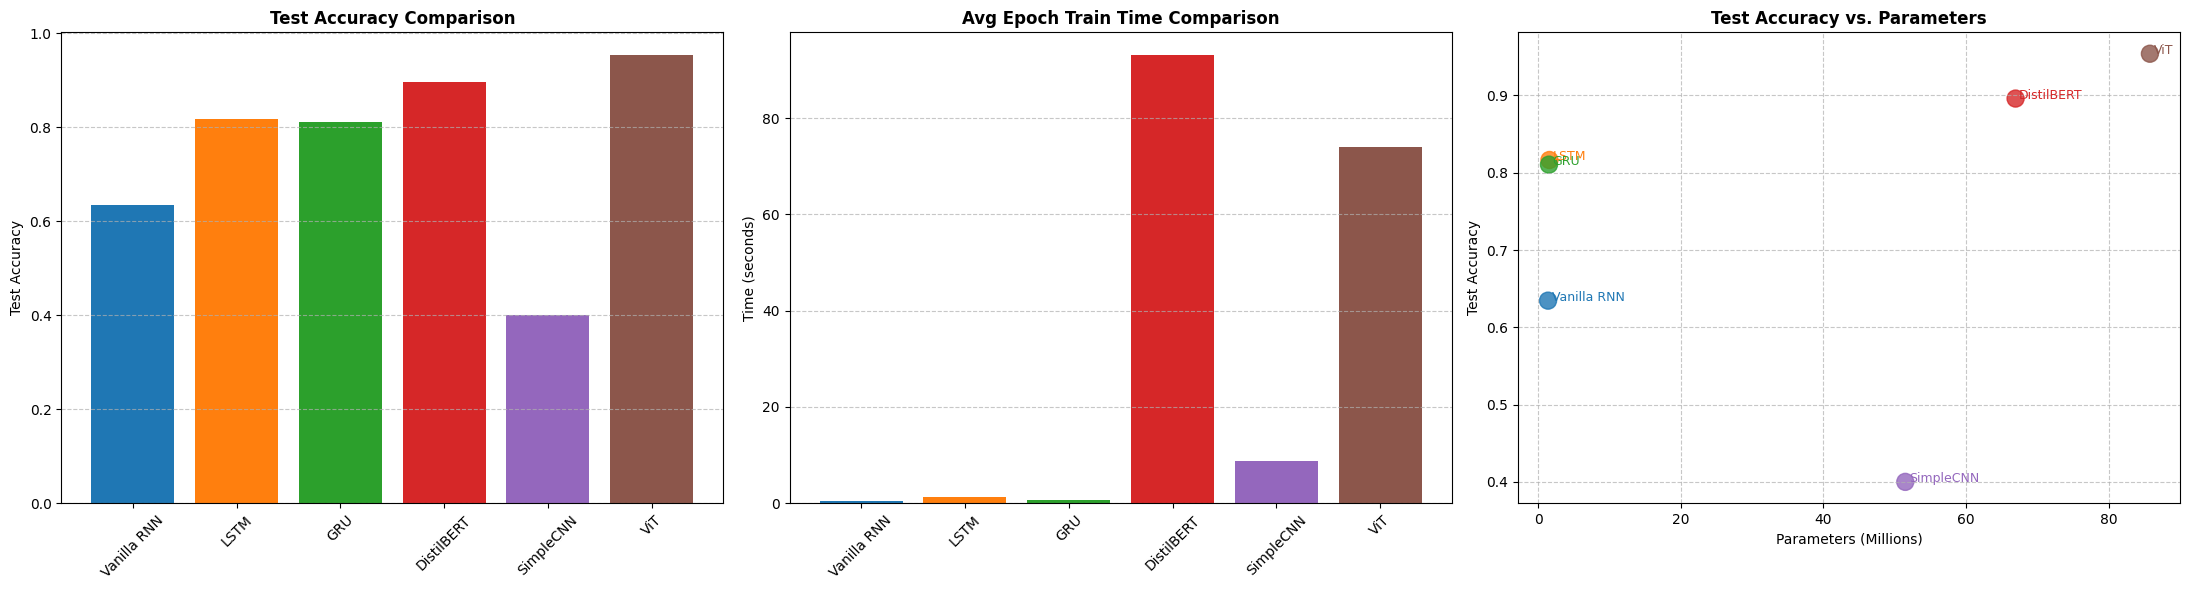

In [64]:
# Cell D.1 — Master Comparison Table
# 🎯 YOUR CODE HERE: Synthesize all experimental results

# Retrieve all metrics (assuming previous cells were run)
# Vanilla RNN
vanilla_acc = vanilla_history['test_acc'][-1]
vanilla_train_time = np.mean(vanilla_history['epoch_times'])
vanilla_params = sum(p.numel() for p in vanilla_model.parameters())

# LSTM
lstm_acc = lstm_history['test_acc'][-1]
lstm_train_time = np.mean(lstm_history['epoch_times'])
lstm_params = sum(p.numel() for p in lstm_model.parameters())

# GRU
gru_acc = gru_history['test_acc'][-1]
gru_train_time = np.mean(gru_history['epoch_times'])
gru_params = sum(p.numel() for p in gru_model.parameters())

# DistilBERT
bert_acc = bert_history['test_acc'][-1]
bert_train_time = np.mean(bert_history['epoch_times'])
bert_params = sum(p.numel() for p in bert_model.parameters())

# CNN (from C.6)
cnn_acc = cnn_accuracy
cnn_train_time = cnn_train_time
cnn_params = cnn_params

# ViT (from C.6)
vit_acc = vit_accuracy
vit_train_time = vit_train_time
vit_params = vit_params

# Compile all results into a list of dictionaries
results_summary = [
    {
        'Model': 'Vanilla RNN',
        'Task': 'Text Classification',
        'Test Accuracy': vanilla_acc,
        'Avg Epoch Train Time (s)': vanilla_train_time,
        'Parameters (M)': vanilla_params / 1_000_000,
        'Key Strengths': 'Simple, very fast',
        'Key Weaknesses': 'Poor at long-term dependencies (vanishing gradient)',
        'Best Use Cases': 'Very short sequences, baseline comparison'
    },
    {
        'Model': 'LSTM',
        'Task': 'Text Classification',
        'Test Accuracy': lstm_acc,
        'Avg Epoch Train Time (s)': lstm_train_time,
        'Parameters (M)': lstm_params / 1_000_000,
        'Key Strengths': 'Captures long-term dependencies, good for sequential data',
        'Key Weaknesses': 'Slower, more parameters than GRU, less performant than Transformers',
        'Best Use Cases': 'Speech recognition, text generation, older NLP tasks'
    },
    {
        'Model': 'GRU',
        'Task': 'Text Classification',
        'Test Accuracy': gru_acc,
        'Avg Epoch Train Time (s)': gru_train_time,
        'Parameters (M)': gru_params / 1_000_000,
        'Key Strengths': 'Captures long-term dependencies, faster & fewer params than LSTM',
        'Key Weaknesses': 'Less performant than Transformers',
        'Best Use Cases': 'Similar to LSTM, often preferred for efficiency'
    },
    {
        'Model': 'DistilBERT',
        'Task': 'Text Classification',
        'Test Accuracy': bert_acc,
        'Avg Epoch Train Time (s)': bert_train_time,
        'Parameters (M)': bert_params / 1_000_000,
        'Key Strengths': 'High accuracy (pre-trained knowledge), excellent for many NLP tasks',
        'Key Weaknesses': 'Computationally expensive (slow per epoch), large parameters',
        'Best Use Cases': 'State-of-the-art NLP tasks, fine-tuning for specific text classification'
    },
    {
        'Model': 'SimpleCNN',
        'Task': 'Image Classification',
        'Test Accuracy': cnn_acc,
        'Avg Epoch Train Time (s)': cnn_train_time,
        'Parameters (M)': cnn_params / 1_000_000,
        'Key Strengths': 'Good for local features, parameter efficient for images, faster training',
        'Key Weaknesses': 'Struggles with global context, lower accuracy than ViT on large datasets',
        'Best Use Cases': 'Image classification, object detection (traditional), smaller datasets'
    },
    {
        'Model': 'ViT',
        'Task': 'Image Classification',
        'Test Accuracy': vit_acc,
        'Avg Epoch Train Time (s)': vit_train_time,
        'Parameters (M)': vit_params / 1_000_000,
        'Key Strengths': 'Excellent accuracy (pre-trained knowledge), captures global relationships, state-of-the-art',
        'Key Weaknesses': 'Computationally very expensive, requires large datasets for pre-training, many parameters',
        'Best Use Cases': 'State-of-the-art image classification, medical imaging, vision tasks needing global context'
    }
]

# Create a well-formatted table
df_summary = pd.DataFrame(results_summary)
df_summary = df_summary.set_index('Model')

print("\n" + "=" * 100)
print("Master Architecture Comparison Table")
print("=" * 100)
display(df_summary.round(4))

# Create visualizations
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# 1. Bar chart comparing Test Accuracies
models = df_summary.index
accuracies = df_summary['Test Accuracy']
colors = plt.cm.tab10(np.arange(len(models)))

axes[0].bar(models, accuracies, color=colors)
axes[0].set_title('Test Accuracy Comparison', fontweight='bold')
axes[0].set_ylabel('Test Accuracy')
axes[0].tick_params(axis='x', rotation=45) # Removed ha='right'
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# 2. Bar chart comparing Average Epoch Train Times
train_times = df_summary['Avg Epoch Train Time (s)']
axes[1].bar(models, train_times, color=colors)
axes[1].set_title('Avg Epoch Train Time Comparison', fontweight='bold')
axes[1].set_ylabel('Time (seconds)')
axes[1].tick_params(axis='x', rotation=45) # Removed ha='right'
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# 3. Scatter plot: Test Accuracy vs Parameters
parameters = df_summary['Parameters (M)']
axes[2].scatter(parameters, accuracies, color=colors, s=150, alpha=0.8)
for i, model in enumerate(models):
    axes[2].annotate(model, (parameters[i] + 0.5, accuracies[i]), fontsize=9, color=colors[i])
axes[2].set_title('Test Accuracy vs. Parameters', fontweight='bold')
axes[2].set_xlabel('Parameters (Millions)')
axes[2].set_ylabel('Test Accuracy')
axes[2].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 📝 Final Reflections


### 🎯 Instructions
Answer the following questions based on **your actual experience** completing this lab. Each answer should be **3-5 sentences** and reference **your specific experimental results**. Generic or theoretical answers will not receive full credit.

---

### **Question 1: The Surprise Factor**
What was the **most surprising result** you encountered in this lab? Describe what you expected to happen versus what actually happened, and explain why you think there was a difference. Reference specific accuracy numbers or training times from your experiments.

1. What surprised me whats how well the ViT performe, but alsothat the LTSM slightly outperformed the GRU model. The LSTM achieved an accuracy of 81.65 %, while the GRU model reached an accuracy of 81.05%. I expected the GRU to perform abot the same way or maybe even better because it is simplier and faster. This could be due to LSTM having more gates and parameters, allowing it to capture more complex long-term dependencies than GRU.
---

### **Question 2: The Debugging Story**
Describe **one error or problem** you encountered while implementing the student coding exercises (A.6, A.7, A.8, etc.). What was the error message or unexpected behavior? How did you figure out what was wrong? What did you learn from fixing it?

2. I ran into a TypeError: 'NoneType' object is not subscriptable in Cell C.4 when I attempted to visualize the ViT attention maps. It happened on the line last_attn = attentions[-1].cpu().mean(dim=1), which told me that attentions was None even though I expected it to contain attention weights.

 I figured it out when I realized that with Hugging Face models, setting output_attentions=True in the forward pass isn’t always enough by itself — the model’s configuration also has to be set to output attentions when the model is loaded. To fix it, I went back to Cell C.2, added config.output_attentions = True, then re-ran Cell C.2, Cell C.3, and finally Cell C.4. What I learned is that some transformer outputs depend on how the model is initialized. If you change something upstream, you have to re-run the dependent cells or the notebook will keep acting broken.



### **Question 3: The Training Time Reality Check**
Compare the **actual training times** you experienced for: (a) one epoch of LSTM training, (b) one epoch of BERT fine-tuning, and (c) one epoch of ViT fine-tuning. Which was fastest? Which was slowest? Did these times match what you expected based on the lecture content? Why or why not?

3. When comparing the models, the LSTM had the fastest training time per epoch, while ViT took the longest. The LSTM trained faster due to its fewer parameters and simpler structure, unlike transformer models. BERT fine-tuning took longer than LSTM since it is a larger pre-trained transformer. ViT was the slowest, which makes sense because it also uses the transformer architecture and has a massive number of parameters.


---

### **Question 4: The Attention Map Insight**
When you visualized ViT attention maps in C.4, describe **one specific image** you analyzed. What class was it? What part of the image did the model focus on most strongly? Did this make sense to you? Did it reveal anything unexpected about how the model "sees"?

4. One specific image I analyzed was a frog. The class the image belonged to was the science category. The model focused most strongly on the frog's face and body, which appeared as the brightest regions in the attention map. At first, it did not make sense to me because the visualization looked very blurry, so I did not fully understand what I was looking at. After looking at it more carefully, I began to realize the model was highlighting the important parts of this. If the image, even with the image being of low resolution, this revealed that the model is actually looking at the image in patches.

---


### **Question 5: The Learning Curve**
Which of the student coding exercises (A.6, A.7, A.8, B.4, B.5, C.4, C.5) did you find **most challenging**? What made it difficult? What strategy did you use to complete it? Looking back, what would you do differently if you had to do it again?

5. The most challenging excercise for me was Cell C4. the ViT Attention Visualization. It was difficult because i was confused on implementing the extract_attention_maps function. The strategy I used was to set output_attentions=true in the model's forward pass, rather than trying to capture the values manually with hooks. If I had to do it again, I would first check the Hugging Face documentation for the ViT model before trying complicated solutions.



---

### **Question 6: The Vanishing Gradient Reality**
Could you explain in your own words why the vanishing gradient problem matters in practice? Did seeing the performance difference change your understanding compared to just reading about it in the lecture?

6. The vanishing gradient problem matters in practice because it makes it difficult for models like vanilla RNNs to remember information from earlier parts of the sequence. In the lab, the Vanilla RNN were the worst model, with an accuracy of 63.45%. The LSTM model handled the problem better, achieving an accuracy of 81.65%. Yes seeing it in action (hands-on) is always better than just reading about it.
---



### **Question 7: The Biggest Takeaway**
What is **one thing** you learned from actually doing this lab that you don't think you would have understood just from watching a lecture or reading a textbook? Why did the hands-on experience make a difference?

7. One thing I learned from doing this lab was how much model architecture affects performance. In module 3, I ran a CNN using transfer learning for 15 epochs and a custom CNN for 10 epochs; it only reached about 50% accuracy. In comparison, the ViT model reached about 95% accuracy. Hands-on experience showed me that transformer-based models can capture more global relationships in images, whereas CNNs primarily focus on local features.

**Write your anwers here or  on the previous cell below the questions. Alway include the number of the question you are replying**





---
## ✅ Submission Checklist

- [ ] **Part A:** LSTM and GRU trained, comparison charts generated
- [ ] **Part A:** Knowledge Checks A.1 and A.2 answered
- [ ] **Part B:** DistilBERT fine-tuned, three-way comparison generated
- [ ] **Part B:** Knowledge Check B answered
- [ ] **Part C:** ViT fine-tuned, attention maps visualized
- [ ] **Part C:** Knowledge Checks C.1 and C.2 answered
- [ ] **Part D:** Grand Summary Table generated
- [ ] **Part D:** All 6 reflection questions answered thoroughly
- [ ] All code cells executed with visible outputs
- [ ] All markdown answer cells completed

### File Naming
`L05_FirstName_LastName_ITAI2376.ipynb`

Example: `L05_Maria_Garcia_ITAI2376.ipynb`

### Submission
Submit your completed `.ipynb` notebook with all cells executed and outputs visible.

---

### 💡 Troubleshooting

- **Out of memory?** Reduce `TRAIN_SIZE` to 4000 or `VIT_TRAIN_SIZE` to 1000
- **No GPU?** Reduce epochs: `NUM_EPOCHS=3`, `BERT_EPOCHS=2`, `VIT_EPOCHS=2`
- **Training too slow?** Reduce `MAX_LEN` to 64
- **Download fails?** Restart runtime and retry
- **Need help?** Schedule an appointment with me to discuss any issues

---
*ITAI 2376 — Deep Learning | Spring 2026 | Houston City College*